In [1]:
.libPaths(c('/project/yangili1/cfbuenabadn/R/x86_64-pc-linux-gnu-library/4.1',
            '/software/R-4.1.0-el8-x86_64/lib64/R/library')) 

# library(glue)
library(tidyverse)
library(dplyr)
library(ggplot2)
library(bedr)
library(readr)

library(ACAT)
library(data.table)
library(ComplexHeatmap)

Warning message:
"'timedatectl' indicates the non-existent timezone name 'n/a'"
unable to deduce timezone name from 'America/Chicago'

-- Attaching packages ------------------------------------------------------------------------------------------------------------------------------------------------------ tidyverse 1.3.1 --

v ggplot2 3.5.2     v purrr   1.0.4
v tibble  3.2.1     v dplyr   1.1.4
v tidyr   1.3.1     v stringr 1.5.1
v readr   1.4.0     v forcats 0.5.1

-- Conflicts --------------------------------------------------------------------------------------------------------------------------------------------------------- tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()



######################
#### bedr v1.0.7 ####
######################

checking binary availability...
  * Checking path for bedtools... PASS
    /scratch/midway3/cnajar/anaconda3/envs/leafcutter2/bin/bedtools
  * Checking path for bedops... FAIL
  * Checki

In [2]:
comparisons <- sub("\\.rds$", "", list.files('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'))

comparisons <- comparisons[!grepl("Bladder", comparisons)]

get_sig_clusters <- function(comparison) {
    path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'
    rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))
    sig_genes <- rds$dge %>% filter(padj <= 1e-4, abs(log2FoldChange) >= 2) %>% pull(gene_id) %>% unique()
    sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.2, p.adjust <= 1e-4, itype=='UP', ctype=='PR,UP',
                                 (gene_id %in% sig_genes)) %>% pull(cluster) %>% unique()
    
    sig_clusters2 <- rds$ds %>% filter(abs(deltapsi) >= 0.2, p.adjust <= 1e-4, itype=='UP', ctype=='PR,UP') %>% pull(cluster) %>% unique()
    return(list(ds_dge=sig_clusters,ds=sig_clusters2))
}

get_sig_clusters2 <- function(comparison) {
    path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'
    rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))
#     sig_genes <- rds$dge %>% filter(padj <= 5e-2, abs(log2FoldChange) >= 0.1) %>% pull(gene_id) %>% unique()
    sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.2, p.adjust <= 1e-4, itype=='UP', ctype=='PR,UP') %>% pull(cluster) %>% unique()
    return(sig_clusters)
}




cluster_list <- c()
cluster_all <- c()


cluster_list2 <- c()
cluster_all2 <- c()
pb = txtProgressBar(min = 0, max = length(comparisons), initial = 0) 
stepi <- 0
for (comparison in comparisons) {
    sig_clusters_list <- get_sig_clusters(comparison)
    cluster_list <- union(cluster_list, sig_clusters_list$ds_dge)
    cluster_all <- c(cluster_all, sig_clusters_list$ds_dge)
    
    
    
    cluster_list2 <- union(cluster_list2, sig_clusters_list$ds)
#     cluster_all2 <- c(cluster_all2, sig_clusters2)
    
    
    setTxtProgressBar(pb,stepi)
    stepi <- stepi + 1
}
close(pb)

In [3]:
length(unique(cluster_list))

[1] 1597

In [4]:
length(unique(cluster_list))

[1] 4596

In [5]:
# comparison <- comparisons[150]
# path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'
# rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))

In [435]:
cluster_all %>% length()

[1] 222079

In [436]:
cluster_list %>% length()

[1] 4596

In [437]:
cluster_list2 %>% length()

[1] 5289

In [4]:
ds_df <- cluster_all %>% table() %>% as.data.frame()
colnames(ds_df) <- c('cluster', 'freq')

In [5]:
# ds_df %>% write_tsv(., 'ds_df.tsv')
# ds_df <- read.table('ds_df.tsv', sep='\t', header=TRUE)

In [6]:
psi <- read.table('../code/analysis_files/GTEx.psi.tsv.gz', sep='\t', header=TRUE)
counts <- read.table('../code/analysis_files/GTEx.cluster_counts.tsv.gz', sep='\t', header=TRUE)
psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), ctype == 'PR,UP') %>% pull(cluster) %>% unique() %>% length()

[1] 1597

In [7]:
# counts

In [8]:
up_psi <- psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), itype == 'UP', ctype == 'PR,UP')
up_psi <- up_psi[rowSums(is.na(up_psi)) <= 0,]

tissues <- (up_psi %>% colnames())[7:56]
X <- up_psi[rowSums(is.na(up_psi)) <= 0, tissues]
rownames(X) <- up_psi[rowSums(is.na(up_psi)) <= 0,]$intron

In [9]:
impute_and_filter <- function(mat) {
  mat %>%
    as.data.frame() %>%
    mutate(row_missing = rowSums(is.na(.))) %>%
    filter(row_missing <= 5) %>%
    select(-row_missing) %>%
    mutate(across(everything(), ~ifelse(is.na(.), mean(., na.rm = TRUE), .)))
}


In [10]:
# X <- X %>% impute_and_filter()

In [11]:
up_psi[rowSums(is.na(up_psi)) <= 5, ] %>% pull(cluster) %>% unique() %>% length()

[1] 591

In [12]:
X %>% dim()

[1] 1013   50

In [13]:
gtex_colors <- list(
  "Adipose.Subcutaneous" = list(
    "tissue_abbrv" = "ADPSBQ", 
    "tissue_color_hex" = "FFA54F", 
    "tissue_color_rgb" = "255,165,79"
  ), 
  "Adipose.Visceral_Omentum" = list(
    "tissue_abbrv" = "ADPVSC", 
    "tissue_color_hex" = "EE9A00", 
    "tissue_color_rgb" = "238,154,0"
  ), 
  "AdrenalGland" = list(
    "tissue_abbrv" = "ADRNLG", 
    "tissue_color_hex" = "8FBC8F", 
    "tissue_color_rgb" = "143,188,143"
  ), 
  "Artery.Aorta" = list(
    "tissue_abbrv" = "ARTAORT", 
    "tissue_color_hex" = "8B1C62", 
    "tissue_color_rgb" = "139,28,98"
  ), 
  "Artery.Coronary" = list(
    "tissue_abbrv" = "ARTCRN", 
    "tissue_color_hex" = "EE6A50", 
    "tissue_color_rgb" = "238,106,80"
  ), 
  "Artery.Femoral" = list(
    "tissue_abbrv" = "ARTFMR", 
    "tissue_color_hex" = "FF4500", 
    "tissue_color_rgb" = "255,69,0"
  ), 
  "Artery.Tibial" = list(
    "tissue_abbrv" = "ARTTBL", 
    "tissue_color_hex" = "FF0000", 
    "tissue_color_rgb" = "255,0,0"
  ), 
  "Bladder" = list(
    "tissue_abbrv" = "BLDDER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Brain.Amygdala" = list(
    "tissue_abbrv" = "BRNAMY", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Anteriorcingulatecortex_BA24" = list(
    "tissue_abbrv" = "BRNACC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Caudate_basalganglia" = list(
    "tissue_abbrv" = "BRNCDT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.CerebellarHemisphere" = list(
    "tissue_abbrv" = "BRNCHB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Cerebellum" = list(
    "tissue_abbrv" = "BRNCHA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Cortex" = list(
    "tissue_abbrv" = "BRNCTXA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.FrontalCortex_BA9" = list(
    "tissue_abbrv" = "BRNCTXB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Hippocampus" = list(
    "tissue_abbrv" = "BRNHPP", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Hypothalamus" = list(
    "tissue_abbrv" = "BRNHPT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Nucleusaccumbens_basalganglia" = list(
    "tissue_abbrv" = "BRNNCC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Putamen_basalganglia" = list(
    "tissue_abbrv" = "BRNPTM", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Spinalcord_cervicalc.1" = list(
    "tissue_abbrv" = "BRNSPC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Substantianigra" = list(
    "tissue_abbrv" = "BRNSNG", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Breast.MammaryTissue" = list(
    "tissue_abbrv" = "BREAST", 
    "tissue_color_hex" = "00CDCD", 
    "tissue_color_rgb" = "0,205,205"
  ), 
  "Cells.EBV.transformedlymphocytes" = list(
    "tissue_abbrv" = "LCL", 
    "tissue_color_hex" = "EE82EE", 
    "tissue_color_rgb" = "238,130,238"
  ), 
  "Cells.Culturedfibroblasts" = list(
    "tissue_abbrv" = "FIBRBLS", 
    "tissue_color_hex" = "9AC0CD", 
    "tissue_color_rgb" = "154,192,205"
  ), 
  "Cervix.Ectocervix" = list(
    "tissue_abbrv" = "CVXECT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Cervix.Endocervix" = list(
    "tissue_abbrv" = "CVSEND", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Colon.Sigmoid" = list(
    "tissue_abbrv" = "CLNSGM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Colon.Transverse" = list(
    "tissue_abbrv" = "CLNTRN", 
    "tissue_color_hex" = "EEC591", 
    "tissue_color_rgb" = "238,197,145"
  ), 
  "Esophagus.GastroesophagealJunction" = list(
    "tissue_abbrv" = "ESPGEJ", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus.Mucosa" = list(
    "tissue_abbrv" = "ESPMCS", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus.Muscularis" = list(
    "tissue_abbrv" = "ESPMSL", 
    "tissue_color_hex" = "CDAA7D", 
    "tissue_color_rgb" = "205,170,125"
  ), 
  "FallopianTube" = list(
    "tissue_abbrv" = "FLLPNT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Heart.AtrialAppendage" = list(
    "tissue_abbrv" = "HRTAA", 
    "tissue_color_hex" = "B452CD", 
    "tissue_color_rgb" = "180,82,205"
  ), 
  "Heart.LeftVentricle" = list(
    "tissue_abbrv" = "HRTLV", 
    "tissue_color_hex" = "7A378B", 
    "tissue_color_rgb" = "122,55,139"
  ), 
  "Kidney.Cortex" = list(
    "tissue_abbrv" = "KDNCTX", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Kidney.Medulla" = list(
    "tissue_abbrv" = "KDNMDL", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Liver" = list(
    "tissue_abbrv" = "LIVER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Lung" = list(
    "tissue_abbrv" = "LUNG", 
    "tissue_color_hex" = "9ACD32", 
    "tissue_color_rgb" = "154,205,50"
  ), 
  "MinorSalivaryGland" = list(
    "tissue_abbrv" = "SLVRYG", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Muscle.Skeletal" = list(
    "tissue_abbrv" = "MSCLSK", 
    "tissue_color_hex" = "7A67EE", 
    "tissue_color_rgb" = "122,103,238"
  ), 
  "Nerve.Tibial" = list(
    "tissue_abbrv" = "NERVET", 
    "tissue_color_hex" = "FFD700", 
    "tissue_color_rgb" = "255,215,0"
  ), 
  "Ovary" = list(
    "tissue_abbrv" = "OVARY", 
    "tissue_color_hex" = "FFB6C1", 
    "tissue_color_rgb" = "255,182,193"
  ), 
  "Pancreas" = list(
    "tissue_abbrv" = "PNCREAS", 
    "tissue_color_hex" = "CD9B1D", 
    "tissue_color_rgb" = "205,155,29"
  ), 
  "Pituitary" = list(
    "tissue_abbrv" = "PTTARY", 
    "tissue_color_hex" = "B4EEB4", 
    "tissue_color_rgb" = "180,238,180"
  ), 
  "Prostate" = list(
    "tissue_abbrv" = "PRSTTE", 
    "tissue_color_hex" = "D9D9D9", 
    "tissue_color_rgb" = "217,217,217"
  ), 
  "Skin.NotSunExposed_Suprapubic" = list(
    "tissue_abbrv" = "SKINNS", 
    "tissue_color_hex" = "3A5FCD", 
    "tissue_color_rgb" = "58,95,205"
  ), 
  "Skin.SunExposed_Lowerleg" = list(
    "tissue_abbrv" = "SKINS", 
    "tissue_color_hex" = "1E90FF", 
    "tissue_color_rgb" = "30,144,255"
  ), 
  "SmallIntestine.TerminalIleum" = list(
    "tissue_abbrv" = "SNTTRM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Spleen" = list(
    "tissue_abbrv" = "SPLEEN", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Stomach" = list(
    "tissue_abbrv" = "STMACH", 
    "tissue_color_hex" = "FFD39B", 
    "tissue_color_rgb" = "255,211,155"
  ), 
  "Testis" = list(
    "tissue_abbrv" = "TESTIS", 
    "tissue_color_hex" = "A6A6A6", 
    "tissue_color_rgb" = "166,166,166"
  ), 
  "Thyroid" = list(
    "tissue_abbrv" = "THYROID", 
    "tissue_color_hex" = "008B45", 
    "tissue_color_rgb" = "0,139,69"
  ), 
  "Uterus" = list(
    "tissue_abbrv" = "UTERUS", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Vagina" = list(
    "tissue_abbrv" = "VAGINA", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "WholeBlood" = list(
    "tissue_abbrv" = "WHLBLD", 
    "tissue_color_hex" = "FF00FF", 
    "tissue_color_rgb" = "255,0,255"
  )
)

In [14]:
library(ComplexHeatmap)
# library(glue)
library(dplyr)

legendBreaks <- seq(-4, 4, 2)
# colors <- rev(RColorBrewer::brewer.pal(length(legendBreaks), "RdBu"))
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )


column_colors <- sapply(colnames(X), function(tissue) {
  paste0("#", gtex_colors[[tissue]]$tissue_color_hex)
})

# Create the heatmap
set.seed(0)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>%
  Heatmap(
    column_title = glue::glue("Unproductive splicing across GTEx tissues, N = {nrow(X)}"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, 
    column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = FALSE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    column_names_gp = gpar(col = column_colors)
  )


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



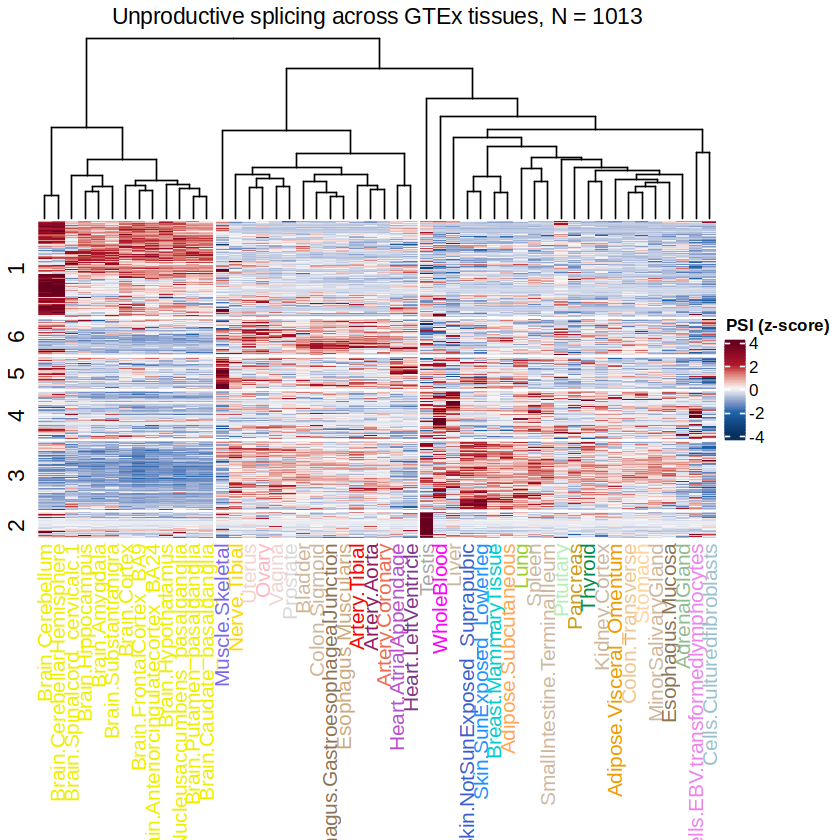

In [15]:
ht

In [16]:
# ht

In [17]:
gtex_colors <- list(
  "Adipose - Subcutaneous" = list(
    "tissue_abbrv" = "ADPSBQ", 
    "tissue_color_hex" = "FFA54F", 
    "tissue_color_rgb" = "255,165,79"
  ), 
  "Adipose - Visceral (omentum)" = list(
    "tissue_abbrv" = "ADPVSC", 
    "tissue_color_hex" = "EE9A00", 
    "tissue_color_rgb" = "238,154,0"
  ), 
  "Adrenal gland" = list(
    "tissue_abbrv" = "ADRNLG", 
    "tissue_color_hex" = "8FBC8F", 
    "tissue_color_rgb" = "143,188,143"
  ), 
  "Artery - Aorta" = list(
    "tissue_abbrv" = "ARTAORT", 
    "tissue_color_hex" = "8B1C62", 
    "tissue_color_rgb" = "139,28,98"
  ), 
  "Artery - Coronary" = list(
    "tissue_abbrv" = "ARTCRN", 
    "tissue_color_hex" = "EE6A50", 
    "tissue_color_rgb" = "238,106,80"
  ), 
  "Artery - Femoral" = list(
    "tissue_abbrv" = "ARTFMR", 
    "tissue_color_hex" = "FF4500", 
    "tissue_color_rgb" = "255,69,0"
  ), 
  "Artery - Tibial" = list(
    "tissue_abbrv" = "ARTTBL", 
    "tissue_color_hex" = "FF0000", 
    "tissue_color_rgb" = "255,0,0"
  ), 
  "Bladder" = list(
    "tissue_abbrv" = "BLDDER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Brain - Amygdala" = list(
    "tissue_abbrv" = "BRNAMY", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Anterior cingulate cortex (BA24)" = list(
    "tissue_abbrv" = "BRNACC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Caudate (basal ganglia)" = list(
    "tissue_abbrv" = "BRNCDT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Cerebellar hemisphere" = list(
    "tissue_abbrv" = "BRNCHB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Cerebellum" = list(
    "tissue_abbrv" = "BRNCHA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Cortex" = list(
    "tissue_abbrv" = "BRNCTXA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Frontal cortex (BA9)" = list(
    "tissue_abbrv" = "BRNCTXB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Hippocampus" = list(
    "tissue_abbrv" = "BRNHPP", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Hypothalamus" = list(
    "tissue_abbrv" = "BRNHPT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Nucleus accumbens (basal ganglia)" = list(
    "tissue_abbrv" = "BRNNCC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Putamen (basal ganglia)" = list(
    "tissue_abbrv" = "BRNPTM", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Spinalcord (cervical c-1)" = list(
    "tissue_abbrv" = "BRNSPC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Substantia nigra" = list(
    "tissue_abbrv" = "BRNSNG", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Breast - Mammary tissue" = list(
    "tissue_abbrv" = "BREAST", 
    "tissue_color_hex" = "00CDCD", 
    "tissue_color_rgb" = "0,205,205"
  ), 
  "Cells - EBV-transformed lymphocytes" = list(
    "tissue_abbrv" = "LCL", 
    "tissue_color_hex" = "EE82EE", 
    "tissue_color_rgb" = "238,130,238"
  ), 
  "Cells - Cultured fibroblasts" = list(
    "tissue_abbrv" = "FIBRBLS", 
    "tissue_color_hex" = "9AC0CD", 
    "tissue_color_rgb" = "154,192,205"
  ), 
  "Cervix - Ectocervix" = list(
    "tissue_abbrv" = "CVXECT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Cervix - Endocervix" = list(
    "tissue_abbrv" = "CVSEND", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Colon - Sigmoid" = list(
    "tissue_abbrv" = "CLNSGM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Colon - Transverse" = list(
    "tissue_abbrv" = "CLNTRN", 
    "tissue_color_hex" = "EEC591", 
    "tissue_color_rgb" = "238,197,145"
  ), 
  "Esophagus - Gastroesophageal junction" = list(
    "tissue_abbrv" = "ESPGEJ", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus - Mucosa" = list(
    "tissue_abbrv" = "ESPMCS", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus - Muscularis" = list(
    "tissue_abbrv" = "ESPMSL", 
    "tissue_color_hex" = "CDAA7D", 
    "tissue_color_rgb" = "205,170,125"
  ), 
  "Fallopian tube" = list(
    "tissue_abbrv" = "FLLPNT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Heart - Atrial appendage" = list(
    "tissue_abbrv" = "HRTAA", 
    "tissue_color_hex" = "B452CD", 
    "tissue_color_rgb" = "180,82,205"
  ), 
  "Heart - Left ventricle" = list(
    "tissue_abbrv" = "HRTLV", 
    "tissue_color_hex" = "7A378B", 
    "tissue_color_rgb" = "122,55,139"
  ), 
  "Kidney - Cortex" = list(
    "tissue_abbrv" = "KDNCTX", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Kidney - Medulla" = list(
    "tissue_abbrv" = "KDNMDL", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Liver" = list(
    "tissue_abbrv" = "LIVER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Lung" = list(
    "tissue_abbrv" = "LUNG", 
    "tissue_color_hex" = "9ACD32", 
    "tissue_color_rgb" = "154,205,50"
  ), 
  "Minor salivary gland" = list(
    "tissue_abbrv" = "SLVRYG", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Muscle - Skeletal" = list(
    "tissue_abbrv" = "MSCLSK", 
    "tissue_color_hex" = "7A67EE", 
    "tissue_color_rgb" = "122,103,238"
  ), 
  "Nerve - Tibial" = list(
    "tissue_abbrv" = "NERVET", 
    "tissue_color_hex" = "FFD700", 
    "tissue_color_rgb" = "255,215,0"
  ), 
  "Ovary" = list(
    "tissue_abbrv" = "OVARY", 
    "tissue_color_hex" = "FFB6C1", 
    "tissue_color_rgb" = "255,182,193"
  ), 
  "Pancreas" = list(
    "tissue_abbrv" = "PNCREAS", 
    "tissue_color_hex" = "CD9B1D", 
    "tissue_color_rgb" = "205,155,29"
  ), 
  "Pituitary" = list(
    "tissue_abbrv" = "PTTARY", 
    "tissue_color_hex" = "B4EEB4", 
    "tissue_color_rgb" = "180,238,180"
  ), 
  "Prostate" = list(
    "tissue_abbrv" = "PRSTTE", 
    "tissue_color_hex" = "D9D9D9", 
    "tissue_color_rgb" = "217,217,217"
  ), 
  "Skin - Not sun exposed (suprapubic)" = list(
    "tissue_abbrv" = "SKINNS", 
    "tissue_color_hex" = "3A5FCD", 
    "tissue_color_rgb" = "58,95,205"
  ), 
  "Skin - Sun exposed (lower leg)" = list(
    "tissue_abbrv" = "SKINS", 
    "tissue_color_hex" = "1E90FF", 
    "tissue_color_rgb" = "30,144,255"
  ), 
  "Small intestine - Terminal ileum" = list(
    "tissue_abbrv" = "SNTTRM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Spleen" = list(
    "tissue_abbrv" = "SPLEEN", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Stomach" = list(
    "tissue_abbrv" = "STMACH", 
    "tissue_color_hex" = "FFD39B", 
    "tissue_color_rgb" = "255,211,155"
  ), 
  "Testis" = list(
    "tissue_abbrv" = "TESTIS", 
    "tissue_color_hex" = "A6A6A6", 
    "tissue_color_rgb" = "166,166,166"
  ), 
  "Thyroid" = list(
    "tissue_abbrv" = "THYROID", 
    "tissue_color_hex" = "008B45", 
    "tissue_color_rgb" = "0,139,69"
  ), 
  "Uterus" = list(
    "tissue_abbrv" = "UTERUS", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Vagina" = list(
    "tissue_abbrv" = "VAGINA", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Whole blood" = list(
    "tissue_abbrv" = "WHLBLD", 
    "tissue_color_hex" = "FF00FF", 
    "tissue_color_rgb" = "255,0,255"
  )
)

In [18]:
colnames(X) <- c(
    'Artery - Aorta', 'Brain - Cortex', 'Brain - Nucleus accumbens (basal ganglia)', 'Esophagus - Muscularis', 
    'Adipose - Visceral (omentum)', 'Adrenal gland', 'Artery - Coronary', 'Bladder', 'Brain - Amygdala', 
    'Brain - Anterior cingulate cortex (BA24)', 'Brain - Caudate (basal ganglia)', 'Brain - Cerebellar hemisphere', 
    'Brain - Cerebellum', 'Brain - Hypothalamus', 'Brain - Putamen (basal ganglia)', 'Brain - Spinalcord (cervical c-1)', 
    'Brain - Substantia nigra', 'Cells - Cultured fibroblasts', 'Esophagus - Gastroesophageal junction', 
    'Esophagus - Mucosa', 'Heart - Atrial appendage', 
    'Heart - Left ventricle', 'Kidney - Cortex', 'Lung', 'Minor salivary gland', 'Ovary', 'Pancreas', 'Pituitary', 
    'Prostate', 'Small intestine - Terminal ileum', 'Spleen', 'Stomach', 'Testis', 'Thyroid', 'Uterus', 'Vagina', 
    'Adipose - Subcutaneous', 'Artery - Tibial', 'Brain - Frontal cortex (BA9)', 'Brain - Hippocampus', 
    'Breast - Mammary tissue', 'Cells - EBV-transformed lymphocytes', 'Colon - Sigmoid', 'Colon - Transverse', 
    'Liver', 'Muscle - Skeletal', 'Nerve - Tibial', 'Skin - Not sun exposed (suprapubic)', 
    'Skin - Sun exposed (lower leg)', 'Whole blood'
)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



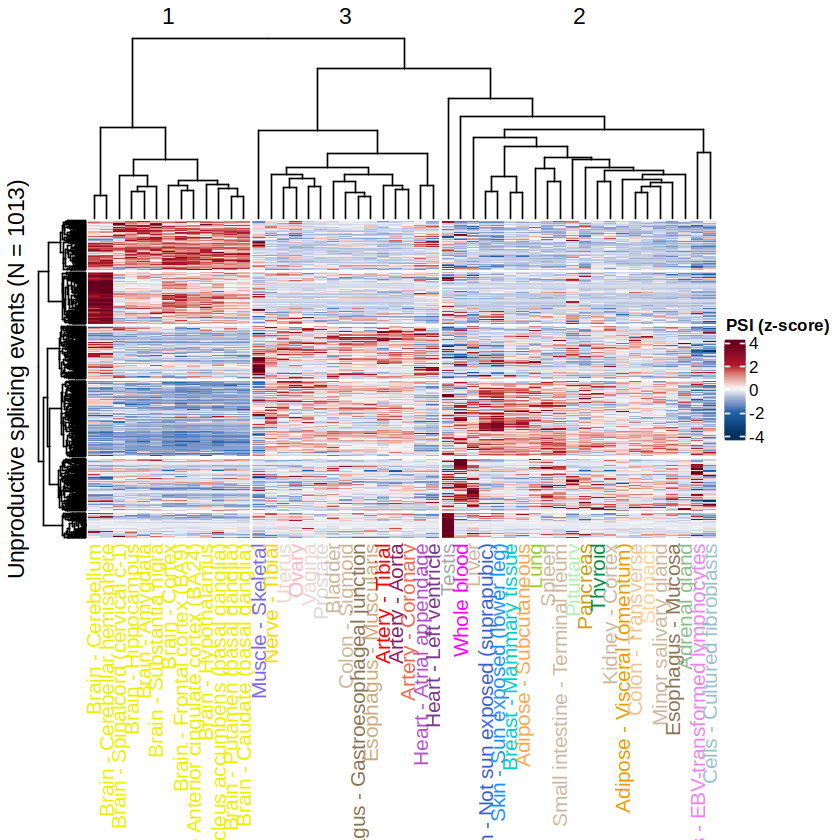

In [19]:
library(ComplexHeatmap)
# library(glue)
library(dplyr)

legendBreaks <- seq(-4, 4, 2)
# colors <- rev(RColorBrewer::brewer.pal(length(legendBreaks), "RdBu"))
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )


column_colors <- sapply(colnames(X), function(tissue) {
  paste0("#", gtex_colors[[tissue]]$tissue_color_hex)
})

# Create the heatmap
set.seed(2)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>%
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, 
    column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = TRUE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    column_names_gp = gpar(col = column_colors)
  )

ht

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



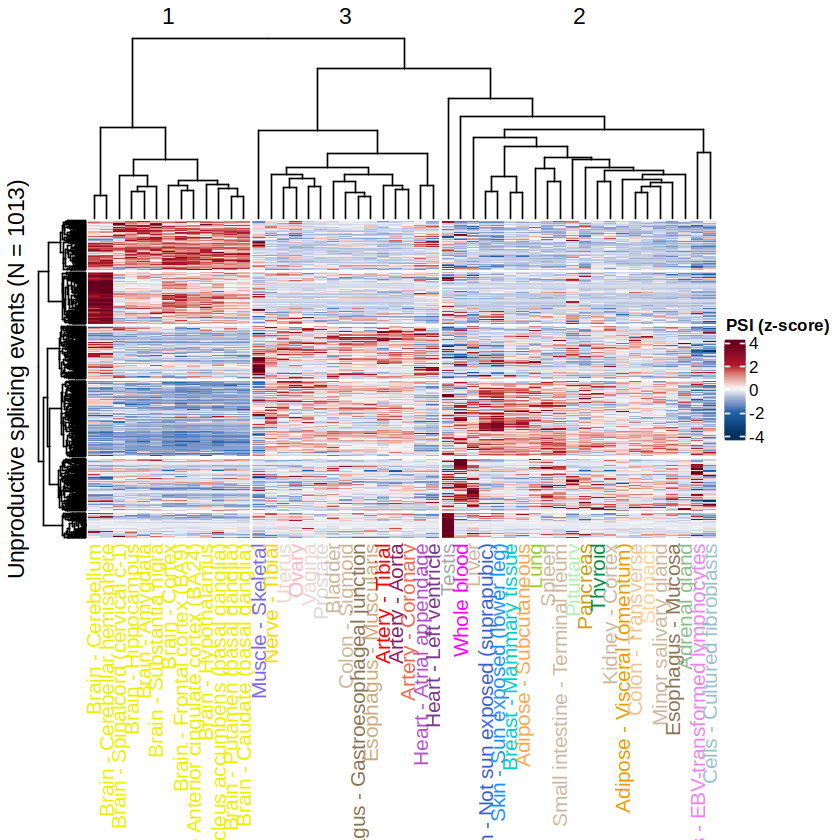

In [20]:
library(ComplexHeatmap)
#library(glue)
library(dplyr)

legendBreaks <- seq(-4, 4, 2)
# colors <- rev(RColorBrewer::brewer.pal(length(legendBreaks), "RdBu"))
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )


column_colors <- sapply(colnames(X), function(tissue) {
  paste0("#", gtex_colors[[tissue]]$tissue_color_hex)
})

# Create the heatmap
set.seed(2)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>%
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, 
    column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = TRUE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    column_names_gp = gpar(col = column_colors)
  )

ht

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



$`1`
 [1] 13 12 16 40  9 17  2 39 10 14  3 15 11

$`3`
 [1] 46 47 35 26 36 29  8 43 19  4 38  1  7 21 22

$`2`
 [1] 33 50 45 48 49 41 37 24 31 30 28 27 34 23  5 44 32 25 20  6 42 18

$`6`
  [1]  351  288  362   56   59   89   88  702  689   19  618  736  248  632  631
 [16]  825  666  252  309  163  357  321  701  432  760  769  232  767  504  134
 [31]  684  682  177  431  292  995  206  205  808  443  141  137  138  140  732
 [46]  614  329  477  944  943  215  913  738  977  520  752  569  114  113  603
 [61]  898  897   36  503  900  605  304  464  726  878  436  233  554  344  647
 [76]  337  649  173  175  671  672  475  476  683  686  251  306  305  852  953
 [91]  954  433  487   74  680  681   22  790  284  981  980  498  500  955  524
[106]  799 1003 1002  510 1010  497  635  463  908  410   23  493  678  677  197
[121]  198  886  642   86   63  964  458  180  435  469   18  405  404  401   65
[136]  733  161  470  250  652  996  997  485  690  914  915  240  890  976  592
[151]  749  576  687  640  307  613  844  817  657  679  511  791  531  282

$`5`
  [1]  673  542    7    6  755  221   55  539  879  880   21  154  381  209  207
 [16]  328  322  525  384  350  988  723  536  905  904  336  124  850   20  709
 [31]  710  972  402  735  989  838  313  529  457  530  834  102  447  448   33
 [46]    2  727  228  793  779  121  122  824  945  946  734  120  783  326  323
 [61]  324   48  386   62  781  780  247  901  903  998  610  871  870  577  119
 [76]  117  118  116  220  688  720  486  638  110  639  919  648  450 1013  792
 [91]   98  316   85   87  317  438  446  867  868  829  830  103  104  963  376
[106]  814  352  353  527  845  243  982  983  984  985  802  724  416   42   41
[121]  164   26   27  860  861  359  358   93  670   15   64  777  467  865  414
[136]  826  145    4    5  293  768  518  650  311  893   43  388  421  256  508
[151]  719  807  599  866  858  725  265  812  715  621  308   78    1  342  818
[166]  703   92  155  533  656  896

$`2`
  [1]  242  244   73  363  563   35  708  160  302  169  948  881  528   77   70
 [16]  706  456   44  572  272  390  106  560  461  459  889  705  862  801  771
 [31]  884  883  126  181  968  496  800  586  806  805  604  742  589  587  588
 [46]  226  612  743  730  211   53  444    3 1008 1007  389  489   49  857  624
 [61]  409  385  565  130  641  109   54  428  615  831  437  505  371  262  662
 [76]   46  746  593  544  546  219  343  254  255  490  403  585  373  217  484
 [91]  131  132  899  602  310  619  620  711  798  514  480  167  283  550  863
[106]  499  543  148  291  921   14   13  667  707  596  318  382   17  664  425
[121]  426   72   71  920  367  951  922  482  877 1001   90   91  970  235  146
[136]  422  147  556  669  668  547  609  770  555  739  740  481  611  494  509
[151]  398  297  692  969  210  341  187  630  629  348  349  185  935  285  442
[166]  325  223   84  937  938  676  571  570

$`3`
  [1]  176  196  266  237  502  507  562  268  143  296  523  949  135  522   40
 [16]  843  257   75  917  916  566  608  643  258  601   96  492  172  171  786
 [31]  787  534  320  115  872  810  231  460  756  295  910  841  839  653  301
 [46]  300  999 1000  633  775  993  804  107  718   99  757  973  449  354  971
 [61]  157  849  960  859  869  454  455   83  194  195  170  975  236  661  828
 [76]  658  654  929  928  751  750  722  234  314  874  788  764  875  782  784
 [91]  853  327  347  245  246  574  491  515  693  691  665  848  451  651   24
[106]  112  551   82   80  909  933  299  128  182  222  406  553  419  418  567
[121]  479  864  312  772  774  471  573  452  519  168  513  417  227  912  213
[136]  212  366  940  731  445  575  994  776   25  150  111  926  927  129  333
[151]  924  846  847  607  151  659  714  700  699  430  429  747  748  694   67
[166]  785  315  156 1012  230  580  581  582  584 1011  885   39  468  625  183
[181]  184  423  891  837  225  851 1009  334  882  856  854  634  823  962  427
[196]  696  813 1005  947   12  166  165  902  396   68  413  100  616  286  260
[211]  261   95  836  835  842  538  537  259  644  822  809  361 1004 1006  991
[226]  516  

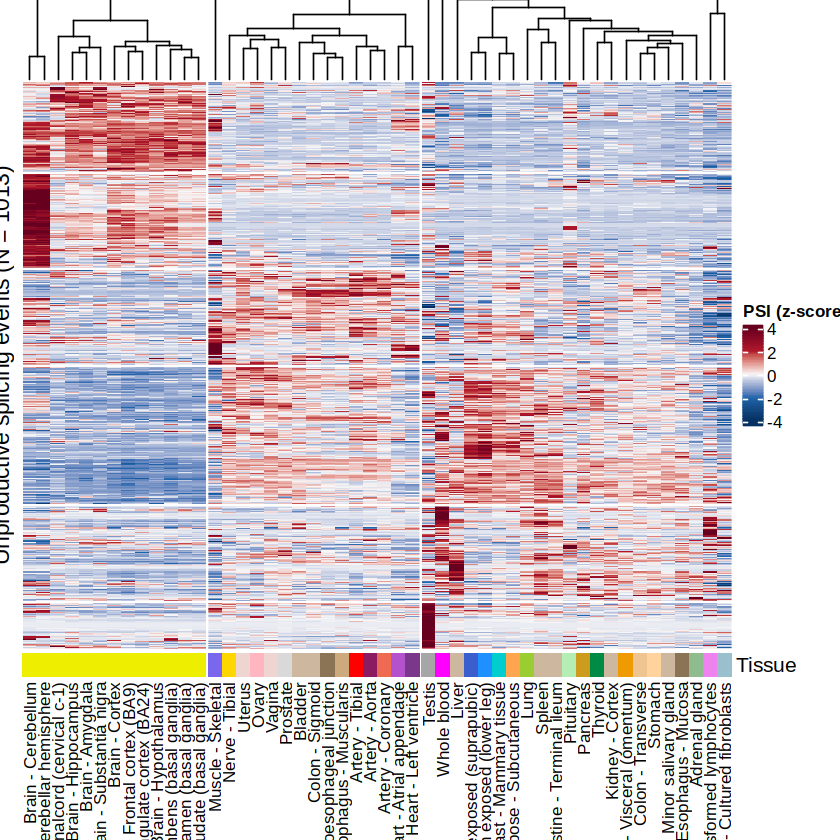

In [21]:
# Define column colors
column_colors <- setNames(
  sapply(colnames(X), function(tissue) paste0("#", gtex_colors[[tissue]]$tissue_color_hex)),
  colnames(X)
)

# Create a heatmap annotation
column_ha <- HeatmapAnnotation(
  Tissue = colnames(X),
  col = list(Tissue = column_colors),
  show_legend = FALSE  # Hide legend if unnecessary
)

# Create the heatmap
set.seed(2)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = FALSE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

# ht

ht = draw(ht); column_order(ht); row_order(ht)
# pdf("heatmap_output.pdf", 
# pdf("../code/plots/fig2_heatmap_aver.pdf",  width = 12, height = 15)  # Set dimensions as needed
# draw(ht, raster_quality = 2)  # Lower value = higher quality
# dev.off()
    
# pdf("../code/plots/fig2_heatmap.pdf",  width = 12, height = 15)  # Set dimensions as needed
# draw(ht, raster_quality = 2)  # Lower value = higher quality
# dev.off()

In [22]:
up_psi %>% pull(cluster) %>% unique() %>% length()

[1] 591

In [23]:
up_psi %>% pull(cluster) %>% unique() %>% length()

[1] 591

In [24]:
X_merge <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% as.data.frame()

X_merge['intron'] <- rownames(X)


up_psi_norm <- merge(up_psi[c('intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id')], 
      X_merge, by = c("intron"))

In [25]:


up_psi_norm <- merge(up_psi[c('intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id')], 
      X_merge, by = c("intron"))

In [26]:
row_clusters <- row_order(ht)

# Convert list to a data frame for easy interpretation
cluster_df <- do.call(rbind, lapply(seq_along(row_clusters), function(i) {
  data.frame(intron = rownames(X)[row_clusters[[i]]], Cluster = i)
}))

colnames(cluster_df) <- c('intron', 'kcluster')
# View the first few rows
head(cluster_df)



up_psi_filter <- up_psi_norm %>% filter(intron %in% cluster_df$intron)
up_psi_filter <- merge(up_psi_filter, cluster_df, by = c("intron"))
up_psi_filter %>% write_tsv(., 'UP_clusters.tsv')

,intron,kcluster
,<chr>,<int>
1,chr17:81713506:81714952:clu_38238_+,1
2,chr17:29617042:29617241:clu_38861_-,1
3,chr18:47134704:47136301:clu_40557_-,1
4,chr11:61334731:61335839:clu_25284_+,1
5,chr11:61335937:61337940:clu_25284_+,1
6,chr12:106312434:106314357:clu_28494_+,1


In [27]:
up_psi_norm %>% dim()

[1] 1013   56

In [28]:
cluster_df %>% dim()

[1] 1013    2

In [29]:
median_expression <- read.table('/project2/mstephens/cfbuenabadn/gtex-stm/code/gtex_tables/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_median_tpm.gct.gz',
                                sep='\t', header=TRUE, skip=2, check.names = FALSE)


In [30]:
up_psi_filter %>% pull(kcluster) %>% table

.
  1   2   3   4   5   6 
164 171 173 250 172  83 

In [31]:
# comparisons <- sub("\\.rds$", "", list.files('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'))
# comparison <- comparisons[1]
# path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'
# rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))

In [32]:
# sig_genes <- rds$dge %>% filter(padj <= 5e-2, abs(log2FoldChange) >= 0.1) %>% pull(gene_id) %>% unique()
# sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.1, p.adjust <= 5e-2, itype=='UP', ctype=='PR,UP',
#                                  gene_id %in% sig_genes) %>% pull(cluster) %>% unique()

In [33]:
# sig_clusters %>% length()

In [34]:
tissues <- (up_psi_filter %>% colnames())[7:56]
up_psi_filter$gene_id <- str_remove(up_psi_filter$gene_id, "\\..*$")
median_expression$gene_id <- str_remove(median_expression$Name, "\\..*$")


In [35]:
# library(stringr)



In [36]:
up_psi_filter

intron,cluster,itype,ctype,gene_name,gene_id,Artery - Aorta,Brain - Cortex,Brain - Nucleus accumbens (basal ganglia),Esophagus - Muscularis,⋯,Cells - EBV-transformed lymphocytes,Colon - Sigmoid,Colon - Transverse,Liver,Muscle - Skeletal,Nerve - Tibial,Skin - Not sun exposed (suprapubic),Skin - Sun exposed (lower leg),Whole blood,kcluster
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
chr10:100498207:100499159:clu_24487_-,chr10:clu_24487_-,UP,"PR,UP",SEC31B,ENSG00000075826,1.313390423,0.27759648,0.11548458,0.13686267,⋯,-1.34565863,-0.60359933,-1.214284458,-0.66198335,-2.98183594,1.584610789,0.21658908,1.32399318,-1.48687789,2
chr10:100508048:100508460:clu_24491_-,chr10:clu_24491_-,UP,"PR,UP",SEC31B,ENSG00000075826,-0.334669260,0.96331068,0.18427978,-0.34169374,⋯,-0.34523788,-0.32667799,-0.325992676,-0.31323172,-0.31928155,-0.319459662,-0.32133905,-0.33300211,-0.31441265,2
chr10:100509102:100516095:clu_24492_-,chr10:clu_24492_-,UP,"PR,UP",SEC31B,ENSG00000075826,1.005187759,0.96443758,-0.62255223,1.77063310,⋯,-0.26476916,1.44318840,0.637593166,0.73285210,0.81564644,-0.996376319,-0.57739232,-0.79581820,-0.65534734,3
chr10:102727157:102727674:clu_23619_+,chr10:clu_23619_+,UP,"PR,UP",SFXN2,ENSG00000156398,-0.099814619,-0.34664242,-0.78422492,-0.58085302,⋯,0.39472861,0.06309750,-0.467787390,-0.41600909,0.26254480,0.189510197,0.71407294,-0.44828932,2.60166396,2
chr10:102727791:102728430:clu_23619_+,chr10:clu_23619_+,UP,"PR,UP",SFXN2,ENSG00000156398,-0.464233590,-0.01258082,-1.19835473,-0.39725527,⋯,-0.24616405,0.11622355,-0.110971218,-0.80426947,0.98827610,-0.663405006,-0.02122327,-0.43463083,1.20629930,2
chr10:102728529:102729722:clu_23620_+,chr10:clu_23620_+,UP,"PR,UP",SFXN2,ENSG00000156398,-0.130271871,0.83507621,2.23419599,0.09156472,⋯,-1.20297879,-0.22940664,-0.908801808,-1.20729647,0.91690519,0.078431247,-0.52197294,-0.51877740,-0.55989767,2
chr10:102729808:102732858:clu_23620_+,chr10:clu_23620_+,UP,"PR,UP",SFXN2,ENSG00000156398,-0.305184658,0.87063353,1.73201574,-0.11952198,⋯,-1.29149132,-0.49090966,-0.959136964,-1.28503341,0.57174278,-0.484640339,-0.53895167,-0.14584134,-0.08548271,2
chr10:112433281:112433540:clu_24581_-,chr10:clu_24581_-,UP,"PR,UP",ZDHHC6,ENSG00000023041,0.003603844,-0.97067566,-1.01707708,-0.09321571,⋯,0.95380831,-0.09707243,0.156270975,-0.61354601,-0.12982374,0.667869867,1.16148574,1.98871121,0.30417637,6
chr10:11257872:11270665:clu_23019_+,chr10:clu_23019_+,UP,"PR,UP",CELF2,ENSG00000048740,-0.413383938,-1.01771509,-0.73703033,-0.41033055,⋯,-0.09359552,-0.33907743,0.070241792,3.40331868,-0.99258707,0.348294989,0.17916233,0.03472721,2.10301181,5


In [37]:
median_expression

Name,Description,Adipose - Subcutaneous,Adipose - Visceral (Omentum),Adrenal Gland,Artery - Aorta,Artery - Coronary,Artery - Tibial,Bladder,Brain - Amygdala,⋯,Skin - Sun Exposed (Lower leg),Small Intestine - Terminal Ileum,Spleen,Stomach,Testis,Thyroid,Uterus,Vagina,Whole Blood,gene_id
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000223972.5,DDX11L1,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.0000000,0.0000000,0.00000000,⋯,0.0000000,0.0000000,0.0000000,0.0000000,0.1664030,0.0000000,0.0000000,0.0000000,0.00000e+00,ENSG00000223972
ENSG00000227232.5,WASH7P,4.0640300,3.3711100,2.68549000,4.0476200,3.90076000,3.6396300,5.1637500,1.43859000,⋯,6.1326500,4.1937800,5.9263100,3.0624800,4.7025300,6.2725500,7.1900100,5.7455400,2.64743e+00,ENSG00000227232
ENSG00000278267.1,MIR6859-1,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.0000000,0.0000000,0.00000000,⋯,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.00000e+00,ENSG00000278267
ENSG00000243485.5,MIR1302-2HG,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.0000000,0.0000000,0.00000000,⋯,0.0000000,0.0000000,0.0000000,0.0000000,0.0542228,0.0000000,0.0000000,0.0000000,0.00000e+00,ENSG00000243485
ENSG00000237613.2,FAM138A,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.0000000,0.0000000,0.00000000,⋯,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.00000e+00,ENSG00000237613
ENSG00000268020.3,OR4G4P,0.0000000,0.0000000,0.03639520,0.0000000,0.00000000,0.0000000,0.0354698,0.04967210,⋯,0.0000000,0.0354079,0.0000000,0.0325904,0.0000000,0.0000000,0.0000000,0.0000000,0.00000e+00,ENSG00000268020
ENSG00000240361.1,OR4G11P,0.0406478,0.0407008,0.05438480,0.0292094,0.00000000,0.0393011,0.0000000,0.06383070,⋯,0.0420410,0.0395775,0.0000000,0.0471121,0.0535776,0.0390580,0.0163333,0.0274644,0.00000e+00,ENSG00000240361
ENSG00000186092.4,OR4F5,0.0453961,0.0446407,0.05797200,0.0000000,0.04123030,0.0444898,0.0438140,0.07886940,⋯,0.0464240,0.0433611,0.0363784,0.0538492,0.0391763,0.0486038,0.0000000,0.0152188,0.00000e+00,ENSG00000186092
ENSG00000238009.6,RP11-34P13.7,0.0184210,0.0214816,0.01615670,0.0000000,0.00796076,0.0000000,0.0146345,0.01904510,⋯,0.0191867,0.0168076,0.0832374,0.0166057,0.3340560,0.0234676,0.0262654,0.0252480,9.64428e-02,ENSG00000238009


In [38]:
colnames(median_expression) <- colnames(median_expression) %>% toupper()
colnames(up_psi_filter) <- colnames(up_psi_filter) %>% toupper()
row_order <- row_order(ht)
col_order <- column_order(ht)
# idx <- match(up_psi_filter[row_order['1'][[1]],]$GENE_ID, median_expression$GENE_ID)
# out <- median_expression[idx[!is.na(idx)], ]

In [39]:
# colnames(median_expression) <- colnames(median_expression) %>% toupper()
# colnames(up_psi) <- colnames(up_psi) %>% toupper()
# row_order <- row_order(ht)
# col_order <- column_order(ht)
# # idx <- match(up_psi_filter[ro

In [40]:
up_X <- X
colnames(up_X) <- colnames(up_X) %>% toupper()

In [41]:
# up_X

In [42]:
# # up_X <- up_psi
# # colnames(up_X) <- colnames(up_X) %>% toupper()

# cols_orders <- c(colnames(X)[col_order['1'][[1]]], colnames(X)[col_order['2'][[1]]], colnames(X)[col_order['3'][[1]]]) %>% toupper()
# idx1 <- match(rownames(up_psi[row_order['1'][[1]],]), median_expression$GENE_ID)
# idx2 <- match(rownames(up_psi[row_order['2'][[1]],]), median_expression$GENE_ID)
# idx3 <- match(rownames(up_psi[row_order['3'][[1]],]), median_expression$GENE_ID)
# idx4 <- match(rownames(up_psi[row_order['4'][[1]],]), median_expression$GENE_ID)
# idx5 <- match(rownames(up_psi[row_order['5'][[1]],]), median_expression$GENE_ID)
# idx6 <- match(rownames(up_psi[row_order['6'][[1]],]), median_expression$GENE_ID)

# rows_orders <- c(idx1, idx2, idx3, idx4, idx5, idx6)

# intron_idx1 <- rownames(up_psi[row_order['1'][[1]],])
# intron_idx2 <- rownames(up_psi[row_order['2'][[1]],])
# intron_idx3 <- rownames(up_psi[row_order['3'][[1]],])
# intron_idx4 <- rownames(up_psi[row_order['4'][[1]],])
# intron_idx5 <- rownames(up_psi[row_order['5'][[1]],])
# intron_idx6 <- rownames(up_psi[row_order['6'][[1]],])

# intron_idx <- c(intron_idx1, intron_idx2, intron_idx3, intron_idx4, intron_idx5, intron_idx6)

# median_expression['BRAIN - SPINALCORD (CERVICAL C-1)'] <- median_expression['BRAIN - SPINAL CORD (CERVICAL C-1)']

# exp_X <- median_expression[rows_orders, cols_orders]
# rownames(exp_X) <- median_expression[rows_orders, 'GENE_ID']

In [43]:
# rows_orders

In [44]:
# up_X <- X
# colnames(up_X) <- colnames(up_X) %>% toupper()

In [45]:
cols_orders <- c(colnames(X)[col_order['3'][[1]]], colnames(X)[col_order['2'][[1]]], colnames(X)[col_order['1'][[1]]]) %>% toupper()
idx1 <- match(up_psi_filter[row_order['3'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx2 <- match(up_psi_filter[row_order['6'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx3 <- match(up_psi_filter[row_order['5'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx4 <- match(up_psi_filter[row_order['4'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx5 <- match(up_psi_filter[row_order['1'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx6 <- match(up_psi_filter[row_order['2'][[1]],]$GENE_ID, median_expression$GENE_ID)

rows_orders <- c(idx1, idx2, idx3, idx4, idx5, idx6)

# median_expression[rows_orders,]

In [46]:
intron_idx1 <- up_psi_filter[row_order['3'][[1]],]$INTRON
intron_idx2 <- up_psi_filter[row_order['6'][[1]],]$INTRON
intron_idx3 <- up_psi_filter[row_order['5'][[1]],]$INTRON
intron_idx4 <- up_psi_filter[row_order['4'][[1]],]$INTRON
intron_idx5 <- up_psi_filter[row_order['1'][[1]],]$INTRON
intron_idx6 <- up_psi_filter[row_order['2'][[1]],]$INTRON

intron_idx <- c(intron_idx1, intron_idx2, intron_idx3, intron_idx4, intron_idx5, intron_idx6)

In [47]:
median_expression['BRAIN - SPINALCORD (CERVICAL C-1)'] <- median_expression['BRAIN - SPINAL CORD (CERVICAL C-1)']

In [48]:
mexp <- median_expression[rows_orders, , drop = FALSE]
rownames(mexp) <- seq_len(nrow(mexp))

new_idx1 <- seq_along(idx1)
new_idx2 <- seq_len(length(idx2)) + max(new_idx1)
new_idx3 <- seq_len(length(idx3)) + max(new_idx2)
new_idx4 <- seq_len(length(idx4)) + max(new_idx3)
new_idx5 <- seq_len(length(idx5)) + max(new_idx4)
new_idx6 <- seq_len(length(idx6)) + max(new_idx5)

mexp$row_id <- seq_len(nrow(mexp))


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



png 
  2

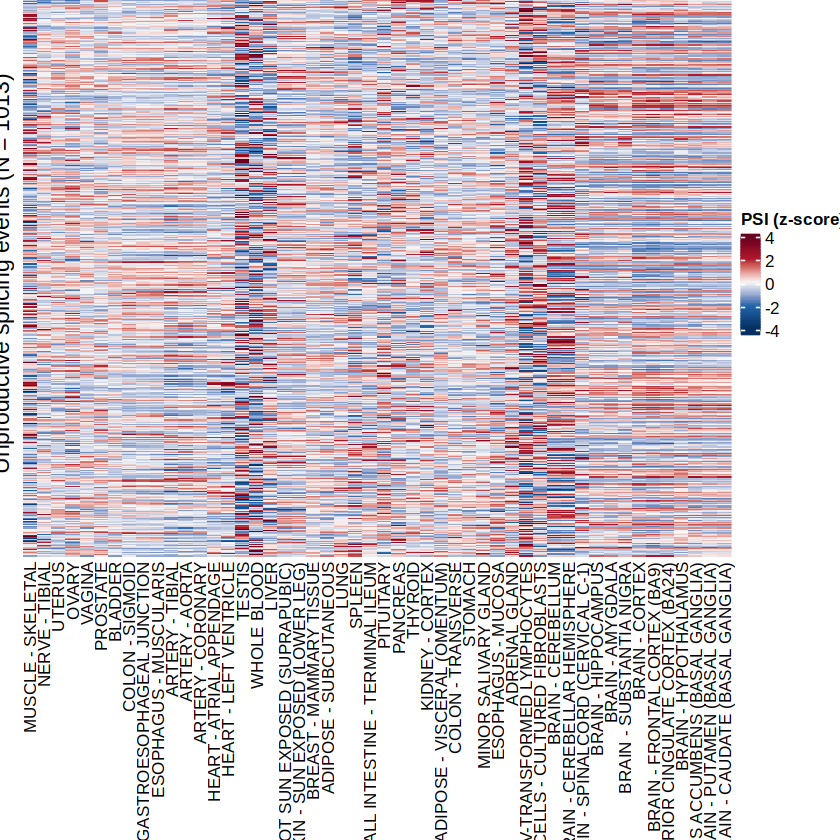

In [49]:
(mexp[,cols_orders] %>% log1p() %>% scale %>% t()%>% scale() %>% t()) %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


pdf("../code/plots/sup_fig2_heatmap_expression_strict.pdf",  width = 12, height = 15)  # Set dimensions as needed
draw(ht, raster_quality = 2)  # Lower value = higher quality
dev.off()

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



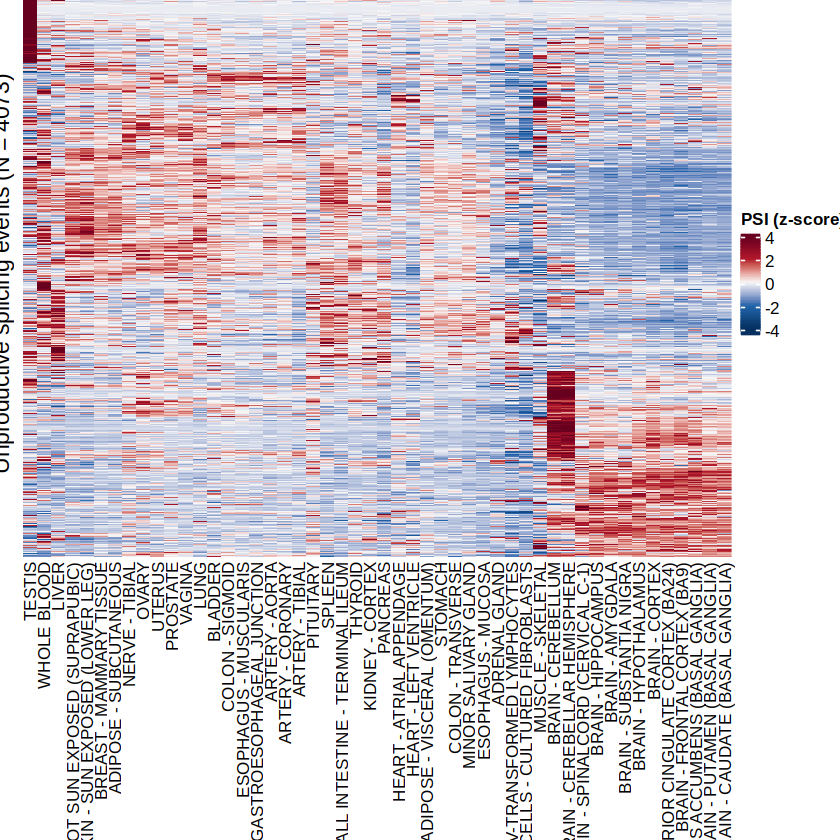

In [73]:
up_X <- up_psi_filter
rownames(up_X) <- up_psi_filter$INTRON
(up_X[intron_idx,cols_orders] %>% t()%>% scale() %>% t()) %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


In [79]:
library(robustbase)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



png 
  2

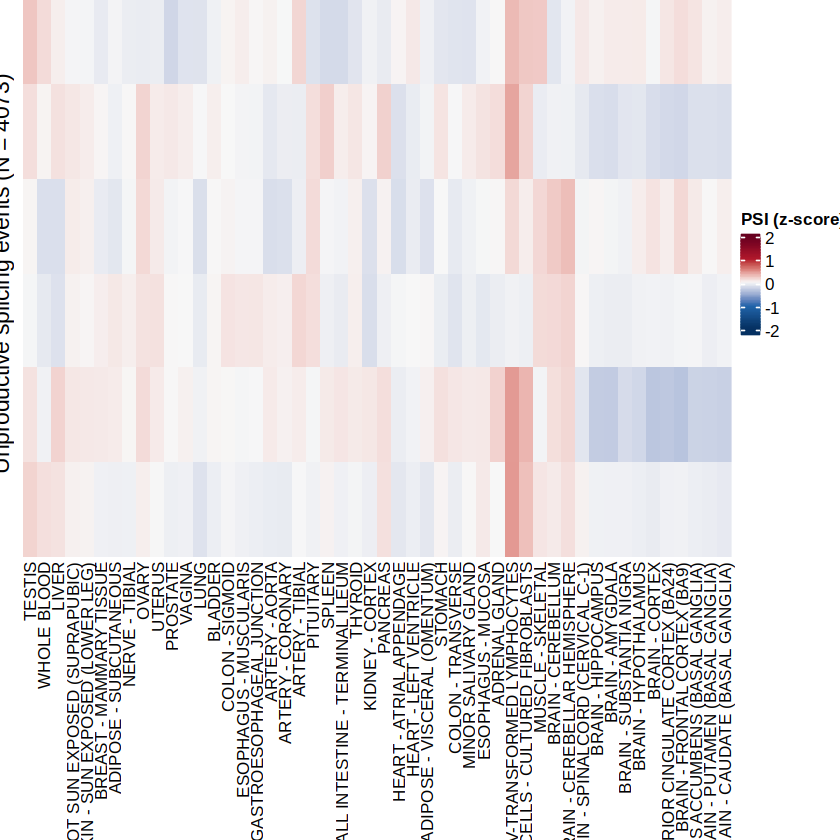

In [85]:
legendBreaks_exp <- seq(-2, 2, 1)

colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc_exp <- circlize::colorRamp2(
  breaks = legendBreaks_exp, 
  colors = colors
  )

mexp_n <- mexp[,cols_orders] %>% log1p() %>% scale %>% t()%>% scale() %>% t()

rbind(mexp_n[new_idx1,cols_orders] %>% colMeans(), 
      mexp_n[new_idx2,cols_orders] %>% colMeans(), 
      mexp_n[new_idx3,cols_orders] %>% colMeans(), 
      mexp_n[new_idx4,cols_orders] %>% colMeans(), 
      mexp_n[new_idx5,cols_orders] %>% colMeans(), 
      mexp_n[new_idx6,cols_orders] %>% colMeans()) %>%

Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc_exp,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

pdf("../code/plots/sup_fig2_heatmap_expression_average.pdf",  width = 12, height = 15)  # Set dimensions as needed
draw(ht, raster_quality = 2)  # Lower value = higher quality
dev.off()

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



png 
  2

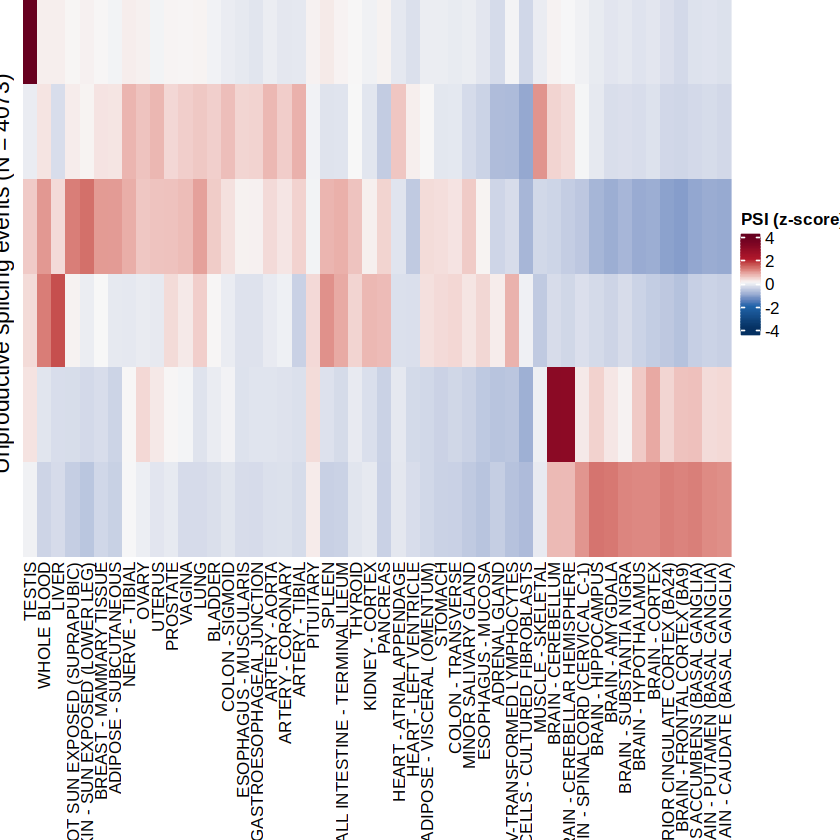

In [86]:
up_X_n <- up_X[intron_idx, cols_orders] %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() 

rbind(up_X_n[intron_idx1,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx2,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx3,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx4,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx5,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx6,cols_orders] %>% colMeans()) %>%
Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

pdf("../code/plots/sup_fig2_heatmap_splicing_average.pdf",  width = 12, height = 15)  # Set dimensions as needed
draw(ht, raster_quality = 2)  # Lower value = higher quality
dev.off()

Warning message:
"The input is a data frame, convert it to the matrix."
'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



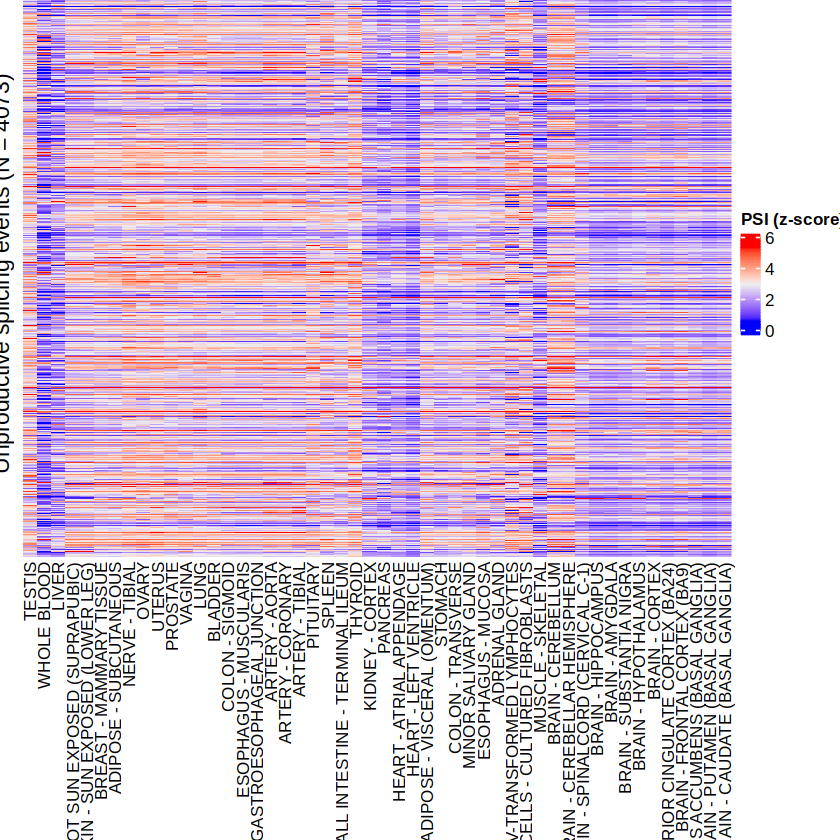

In [778]:
(mexp[,cols_orders] %>% log1p()) %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    # col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



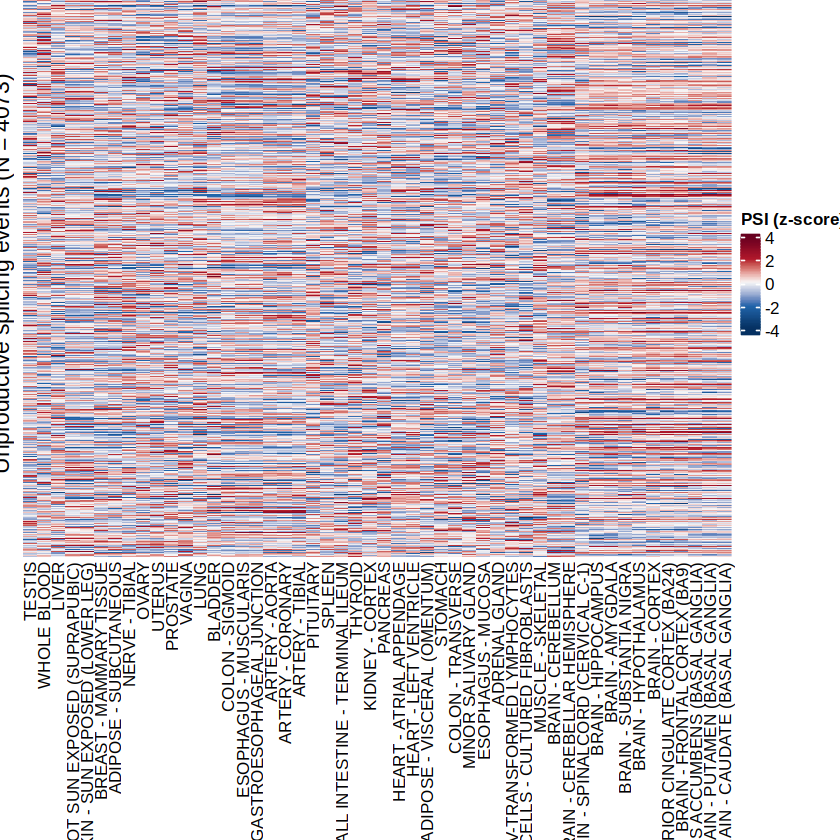

In [658]:
mat_rank %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


In [656]:

mat0 <- median_expression[rows_orders,cols_orders] %>% log1p()
mat_z <- t(scale(t(mat0)))
mat_rank <- apply(mat_z, 2, function(x) {
  qnorm((rank(x, ties.method = "average") - 0.5) / length(x))
})


# ((median_expression[,cols_orders] %>% log1p() %>% scale) %>% as.data.frame() %>% drop_na())

In [717]:
mat0 <-mexp[,cols_orders] %>% log1p()
mat_z <- t(scale(t(mat0)))
mat_rank <- apply(mat_z, 2, function(x) {
  qnorm((rank(x, ties.method = "average") - 0.5) / length(x))
})

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



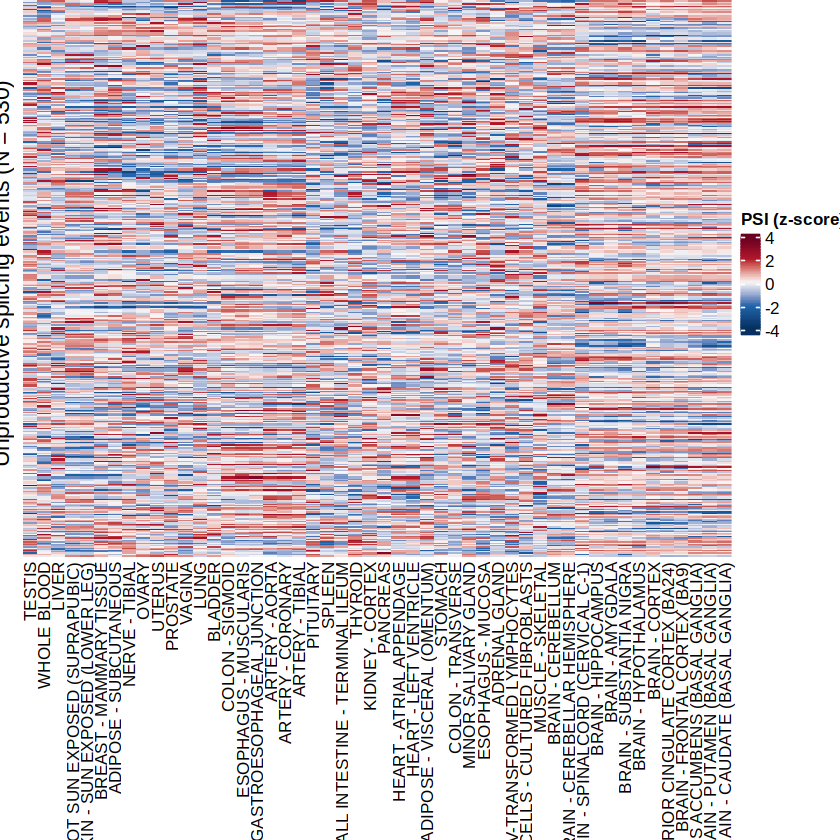

In [720]:
mat_rank[new_idx3,] %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {length(new_idx3)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


In [729]:
mat_rank[new_idx3,]  %>% as.data.frame() %>% pull(TESTIS) %>% mean()

[1] 0.09183223

In [705]:
(median_expression[idx3,] %>% pull(NAME) %>% sort())[1:10]

[1] "ENSG00000001629.9"  "ENSG00000001629.9"  "ENSG00000001629.9" 
 [4] "ENSG00000002822.15" "ENSG00000002822.15" "ENSG00000006607.13"
 [7] "ENSG00000006607.13" "ENSG00000006715.15" "ENSG00000006715.15"
[10] "ENSG00000008441.16"

In [706]:
(psi %>% filter(intron %in% intron_idx3) %>% pull(gene_id) %>% sort())[1:10]

[1] "ENSG00000001629.9"  "ENSG00000001629.9"  "ENSG00000001629.9" 
 [4] "ENSG00000002822.15" "ENSG00000002822.15" "ENSG00000006607.13"
 [7] "ENSG00000006607.13" "ENSG00000006715.15" "ENSG00000006715.15"
[10] "ENSG00000008441.16"

In [757]:
(psi %>% filter(intron %in% intron_idx6) ) %>% drop_na() %>% pull(Testis) %>% mean()

[1] 0.07465699

In [674]:
median_expression[idx3,] 

,NAME,DESCRIPTION,ADIPOSE - SUBCUTANEOUS,ADIPOSE - VISCERAL (OMENTUM),ADRENAL GLAND,ARTERY - AORTA,ARTERY - CORONARY,ARTERY - TIBIAL,BLADDER,BRAIN - AMYGDALA,⋯,SMALL INTESTINE - TERMINAL ILEUM,SPLEEN,STOMACH,TESTIS,THYROID,UTERUS,VAGINA,WHOLE BLOOD,GENE_ID,BRAIN - SPINALCORD (CERVICAL C-1)
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
24335,ENSG00000104375.15,STK3,12.57790,10.10740,9.34837,11.84400,12.23150,13.80360,11.00100,1.70604,⋯,5.25440,5.11302,4.41078,11.90470,8.27586,18.19690,11.96810,1.813320,ENSG00000104375,4.91868
35425,ENSG00000180776.15,ZDHHC20,18.30430,16.35760,11.55680,23.49700,19.89350,22.08990,20.27230,9.88938,⋯,19.79990,20.88150,18.63390,28.43850,21.39670,24.97420,31.44830,25.783800,ENSG00000180776,71.07850
21438,ENSG00000001629.9,ANKIB1,20.42220,17.30820,14.35800,22.86800,23.34170,25.00200,18.27630,15.19950,⋯,15.40230,14.59880,10.53610,28.06100,20.66130,21.35610,19.16850,2.329050,ENSG00000001629,25.52960
154,ENSG00000157881.13,PANK4,15.06030,12.72130,12.19620,15.41640,15.02350,17.21400,18.95290,5.45738,⋯,16.13050,19.88820,11.61250,17.68610,21.81860,22.20060,17.04930,10.440300,ENSG00000157881,7.24343
13005,ENSG00000163291.14,PAQR3,6.83594,4.32823,2.44677,6.75344,6.64388,6.67970,5.42650,4.65162,⋯,5.99558,2.63836,2.01086,27.45260,5.20266,10.25410,6.01977,0.497240,ENSG00000163291,12.63360
50125,ENSG00000101247.17,NDUFAF5,4.97494,3.86829,3.33064,4.20077,4.39551,5.44347,6.13061,3.06828,⋯,4.30601,3.94094,3.51430,8.13990,4.72167,6.39259,5.34849,0.660316,ENSG00000101247,3.86371
50125.1,ENSG00000101247.17,NDUFAF5,4.97494,3.86829,3.33064,4.20077,4.39551,5.44347,6.13061,3.06828,⋯,4.30601,3.94094,3.51430,8.13990,4.72167,6.39259,5.34849,0.660316,ENSG00000101247,3.86371
43949,ENSG00000178307.9,TMEM11,19.26210,18.12310,10.35920,15.42700,14.71540,17.08410,13.95330,6.25134,⋯,11.61750,13.97340,10.90990,21.17580,17.33870,16.96300,16.73070,11.173000,ENSG00000178307,9.19903
47738,ENSG00000132010.15,ZNF20,2.33854,1.84639,2.68201,2.75022,2.81593,2.63053,3.45523,1.02863,⋯,2.70989,3.65751,2.22044,17.92180,4.87205,4.23291,3.60031,1.270850,ENSG00000132010,1.28670


In [775]:
counts %>% filter(intron %in% intron_idx3) %>%  pull(Pancreas_v_Testis) %>% mean(na.rm = TRUE)

[1] 102.8381

In [654]:
mat_rank %>% as.data.frame() %>% pull(OVARY) %>% mean()

[1] 3.313756e-05

In [522]:
exp_X <- median_expression[rows_orders, cols_orders]

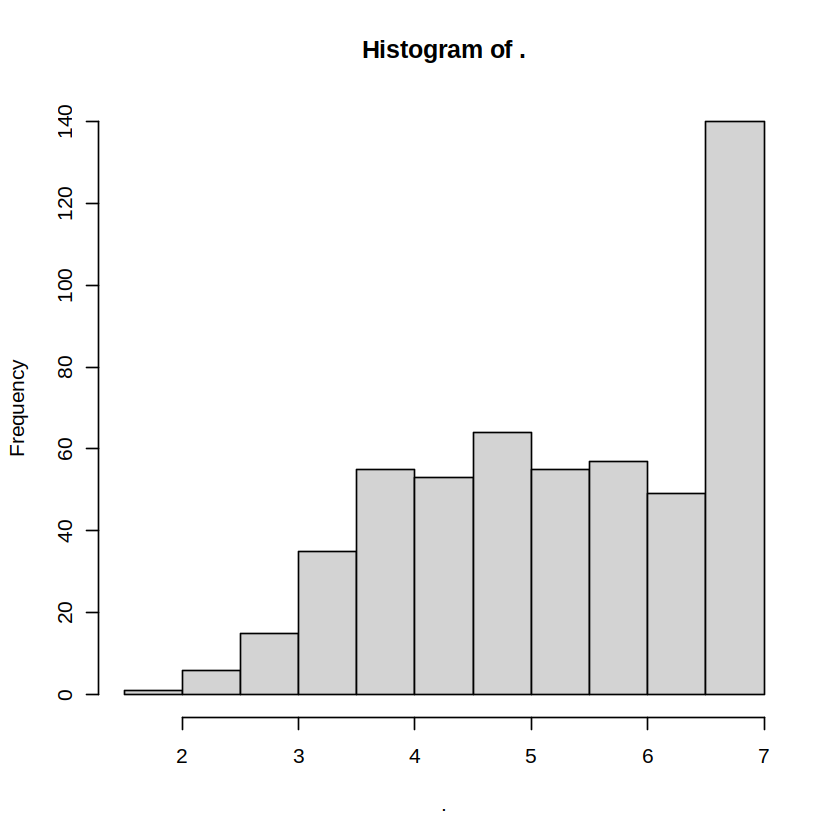

In [538]:
up_psi_filter[row_order['3'][[1]],] %>% pull(TESTIS) %>% hist()

In [542]:
exp_X <- median_expression[idx3, cols_orders]

In [543]:
exp_X

,TESTIS,WHOLE BLOOD,LIVER,SKIN - NOT SUN EXPOSED (SUPRAPUBIC),SKIN - SUN EXPOSED (LOWER LEG),BREAST - MAMMARY TISSUE,ADIPOSE - SUBCUTANEOUS,NERVE - TIBIAL,OVARY,UTERUS,⋯,BRAIN - HIPPOCAMPUS,BRAIN - AMYGDALA,BRAIN - SUBSTANTIA NIGRA,BRAIN - HYPOTHALAMUS,BRAIN - CORTEX,BRAIN - ANTERIOR CINGULATE CORTEX (BA24),BRAIN - FRONTAL CORTEX (BA9),BRAIN - NUCLEUS ACCUMBENS (BASAL GANGLIA),BRAIN - PUTAMEN (BASAL GANGLIA),BRAIN - CAUDATE (BASAL GANGLIA)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
24335,11.90470,1.813320,4.077490,7.51076,7.65141,11.17640,12.57790,13.02790,17.60400,18.19690,⋯,1.71115,1.70604,2.27870,1.65613,1.66872,1.37110,1.62484,1.41042,1.489780,1.74838
35425,28.43850,25.783800,6.571650,26.65170,25.07860,17.07800,18.30430,24.01230,17.23250,24.97420,⋯,15.08900,9.88938,25.60940,20.48790,8.29135,8.58447,11.87350,9.42644,8.505750,8.60592
21438,28.06100,2.329050,4.514380,19.95630,20.25280,18.17060,20.42220,22.95590,22.73260,21.35610,⋯,15.28190,15.19950,20.36990,17.99020,12.53590,12.21830,13.95340,14.55400,13.274700,15.60400
154,17.68610,10.440300,7.019300,15.52340,18.28620,14.80170,15.06030,19.65400,16.27850,22.20060,⋯,6.25197,5.45738,5.32553,7.53273,14.95820,8.60113,13.66990,11.29290,7.284950,9.05984
13005,27.45260,0.497240,1.658050,8.10295,8.17197,5.76624,6.83594,9.63570,6.70230,10.25410,⋯,5.72989,4.65162,5.81960,7.21175,7.23570,5.92892,9.26403,7.73672,5.661640,7.84243
50125,8.13990,0.660316,2.252040,5.91161,6.06736,5.21771,4.97494,6.92286,4.38723,6.39259,⋯,3.59625,3.06828,3.23286,4.29110,5.71348,4.97326,7.47678,4.66082,3.155420,4.05114
50125.1,8.13990,0.660316,2.252040,5.91161,6.06736,5.21771,4.97494,6.92286,4.38723,6.39259,⋯,3.59625,3.06828,3.23286,4.29110,5.71348,4.97326,7.47678,4.66082,3.155420,4.05114
43949,21.17580,11.173000,6.645240,21.67210,21.21390,17.99720,19.26210,15.12440,12.37400,16.96300,⋯,6.41523,6.25134,7.20305,7.95405,8.27352,7.08125,9.60261,7.23670,6.336350,6.93021
47738,17.92180,1.270850,0.888061,3.06429,3.26795,3.24428,2.33854,4.16391,3.64552,4.23291,⋯,1.05558,1.02863,1.14523,1.47192,1.17226,1.06588,1.21345,1.08784,0.898056,1.20224


In [524]:
# up_X[intron_idx,cols_orders]#,]

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



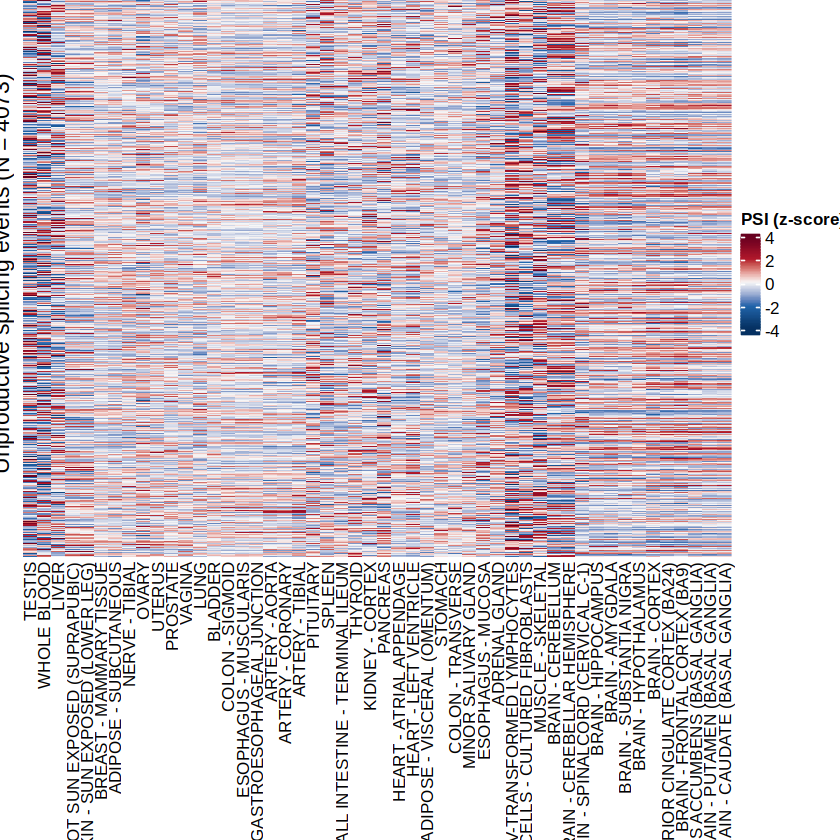

In [525]:
# column_ha <- HeatmapAnnotation(
#   Tissue = colnames(exp_X),
#   col = list(Tissue = column_colors),
#   show_legend = FALSE  # Hide legend if unnecessary
# )

exp_X %>% log1p() %>% scale %>% t()%>% scale() %>% t() %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


In [526]:
up_X[intron_idx,cols_orders] %>% t()%>% scale() %>% t() %>% write.table(., 'up_X.tab', quote=FALSE, sep='\t')

In [527]:
exp_X %>% log1p() %>% scale %>% t()%>% scale() %>% t() %>% write.table(., 'exp_X.tab', quote=FALSE, sep='\t')

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



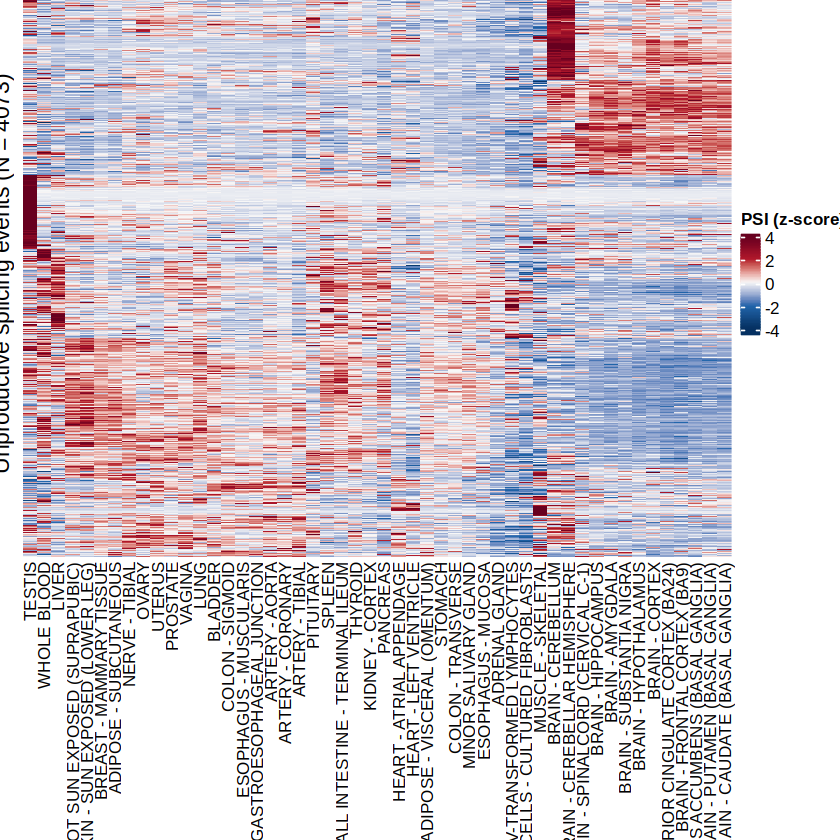

In [528]:
up_X[intron_idx,cols_orders] %>% t()%>% scale() %>% t() %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

In [397]:
tissues_v <- (counts %>% colnames())[7:1231]
result <- counts %>% filter(ctype == 'PR,UP') %>%
  # 1. Filter rows with at most 40% NA in tissue columns
  filter(
    rowMeans(is.na(across(all_of(tissues_v)))) <= 0.4
  ) %>%
  
  # 2. Replace remaining NA with 0 in tissue columns
  mutate(
    across(all_of(tissues_v), ~ replace_na(.x, 0))
  ) %>%
  
  # 3. Compute median across tissues
  rowwise() %>%
  mutate(
    median_tissue = mean(c_across(all_of(tissues_v)))
  ) %>%
  ungroup() %>%
  
  # 4. For each gene_id, keep the row with the highest median
  group_by(gene_id) %>%
  slice_max(median_tissue, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  
  # 5. Select requested output columns
  select(cluster, gene_name, gene_id, median_tissue)

In [398]:
idx1 <- match(up_psi_filter[row_order['1'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx2 <- match(up_psi_filter[row_order['2'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx3 <- match(up_psi_filter[row_order['3'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx4 <- match(up_psi_filter[row_order['4'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx5 <- match(up_psi_filter[row_order['5'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx6 <- match(up_psi_filter[row_order['6'][[1]],]$GENE_ID, median_expression$GENE_ID)

rows_orders <- c(idx1, idx2, idx3, idx4, idx5, idx6)

In [399]:
# up_psi_filter[row_order['3'][[1]],] %>% filter(CLUSTER %in% result$cluster) 

idx3_ <- match((up_psi_filter[row_order['3'][[1]],] %>% filter(CLUSTER %in% result$cluster,))$GENE_ID, median_expression$GENE_ID)
#%>% pull(TESTIS) %>% hist()

In [411]:
intron_idx1 <- up_psi_filter[row_order['1'][[1]],]$INTRON
intron_idx2 <- up_psi_filter[row_order['2'][[1]],]$INTRON
intron_idx3 <- up_psi_filter[row_order['3'][[1]],]$INTRON
intron_idx4 <- up_psi_filter[row_order['4'][[1]],]$INTRON
intron_idx5 <- up_psi_filter[row_order['5'][[1]],]$INTRON
intron_idx6 <- up_psi_filter[row_order['6'][[1]],]$INTRON

intron_idx <- c(intron_idx1, intron_idx2, intron_idx3, intron_idx4, intron_idx5, intron_idx6)

In [412]:
mexp_tissues <- c(colnames(median_expression)[3:56], 'BRAIN - SPINALCORD (CERVICAL C-1)')

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



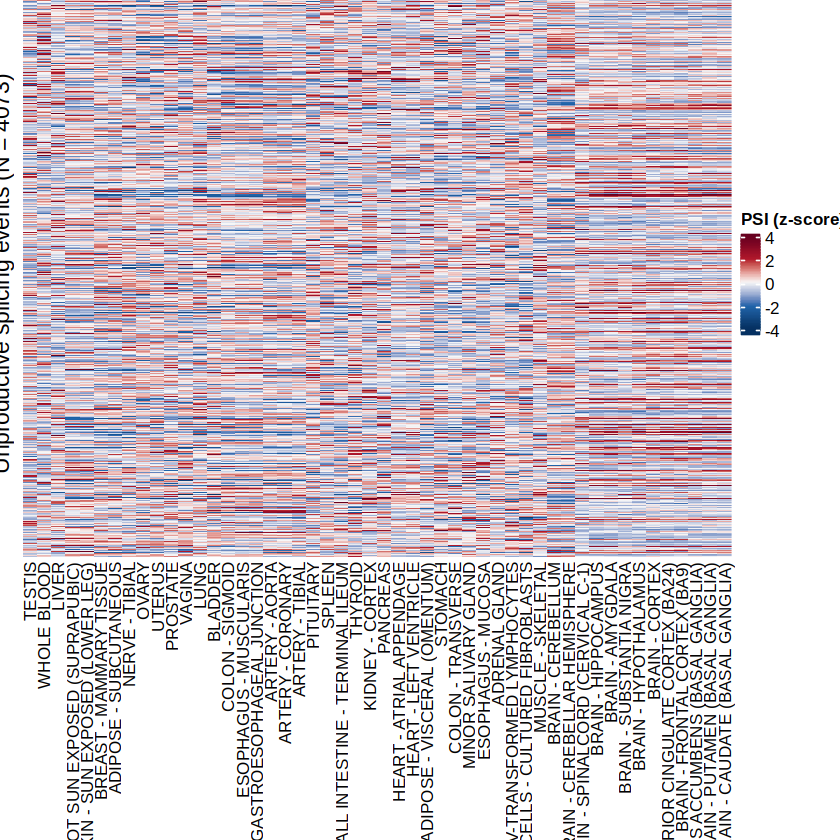

In [413]:
(median_expression[rows_orders, cols_orders] %>%log1p() %>% t() %>% scale() %>% t() %>% scale()) %>% #as.data.frame() #%>% heatmap()
Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

In [273]:
# median_expression[idx3,] 

In [87]:
psi %>% dim()

[1] 154681     56

In [90]:
tissues <- colnames(psi)[7:56]

In [428]:
tissues <- colnames(psi)[7:56]
top_psi <- psi %>% filter(cluster %in% result$cluster, ctype == 'PR,UP', itype=='UP') %>%
filter(
    rowMeans(is.na(across(all_of(tissues)))) <= 0.25
  ) %>%
  
  # 2. Replace remaining NA with 0 in tissue columns
  mutate(
    across(all_of(tissues), ~ replace_na(.x, 0))
  ) %>%
filter(
    rowMeans(across(all_of(tissues))) >= 0.25
  ) %>%
rowwise() %>%
  filter(
    max(c_across(all_of(tissues))) >= 0.5
  ) %>%

# rowwise() %>%
  mutate(
    mean_tissue = mean(c_across(all_of(tissues)))
  ) %>%
  ungroup() %>%
  
  # 4. For each gene_id, keep the row with the highest median
  group_by(gene_id) %>%
  slice_max(mean_tissue, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  
  # 5. Select requested output columns
  select(intron, cluster, gene_name, gene_id, mean_tissue)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



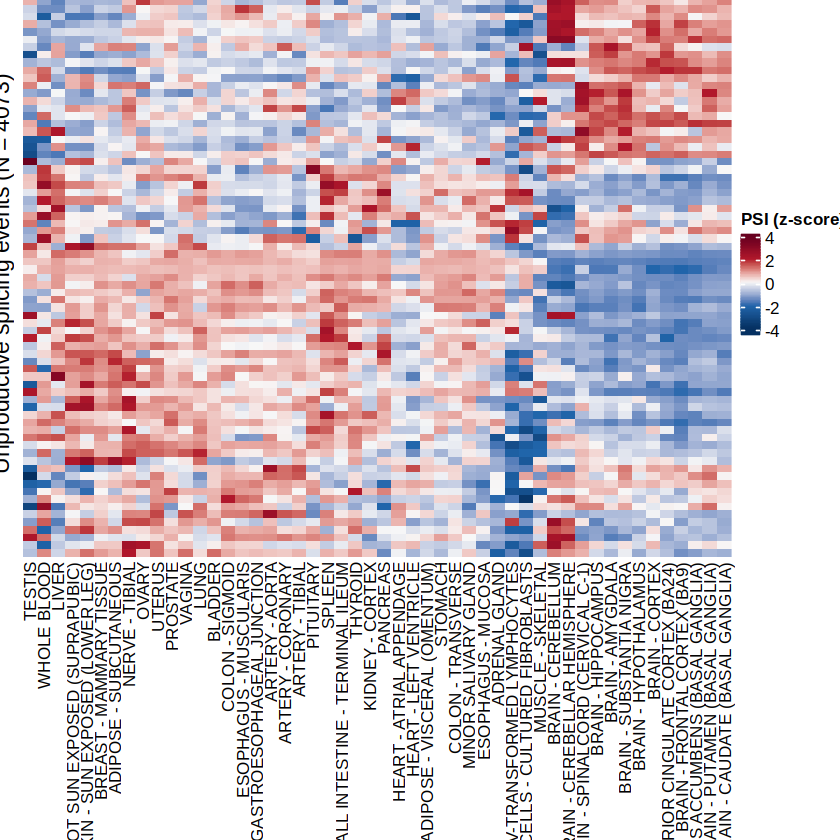

In [429]:
up_filtered_X <- up_X[intron_idx[intron_idx %in% top_psi[top_psi$cluster %in% top_pr$cluster,]$intron],cols_orders]
up_filtered_X %>% t()%>% scale() %>% t() %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


In [430]:
rows_orders[intron_idx %in% top_psi[top_psi$cluster %in% top_pr$cluster,]$intron]

[1] 18214 14506 51809  9544 39393  3432 54212 52315 52981 26255 12196   213
[13] 42581 48204  1641   480 46254 36499 22531 35686 21029 19288 45675 23164
[25] 47563  9654 35297  2175 41320 28635 22768 34005 37104 34679  2342 40898
[37] 18072 53922 22544 40998 54083  3175  3886 17603 23212  3602  6151 22170
[49]  8043  1805 17974  2457 16980 51878 21376  4679 44487 11943 39419 36730
[61] 36940   127 11502 32664  5799 49137 48119 24190  4190  3164   158 42647
[73]   729 43577

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



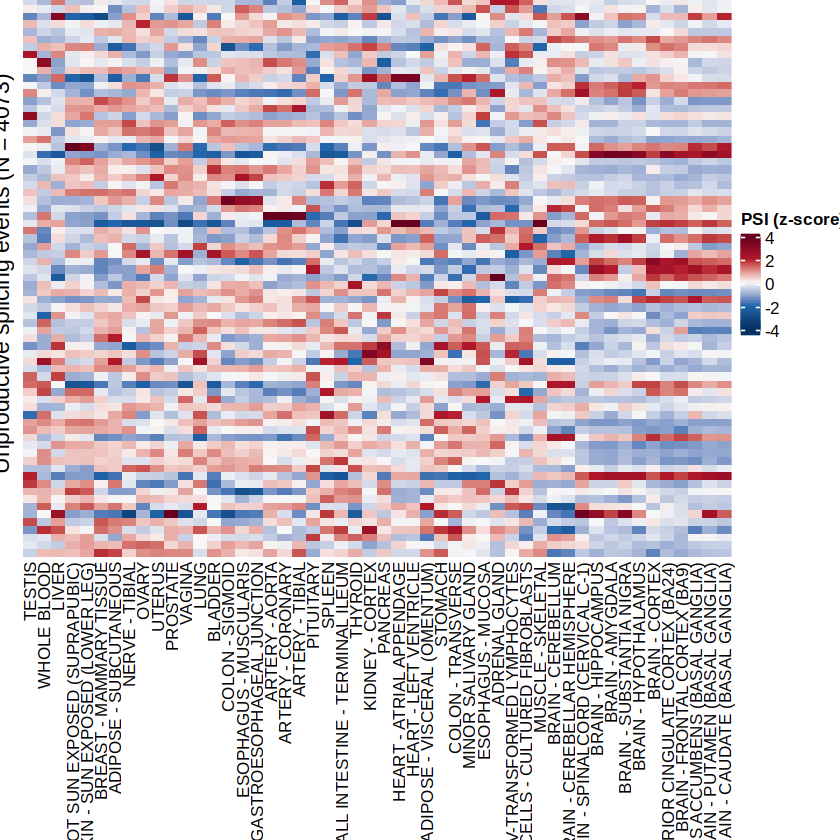

In [431]:
(median_expression[rows_orders[intron_idx %in% top_psi[top_psi$cluster %in% top_pr$cluster,]$intron], cols_orders] %>%log1p() %>% t() %>% scale() %>% t() %>% scale()) %>% #as.data.frame() #%>% heatmap()
Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

In [313]:
# 

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50

[1]   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
 [19]  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
 [37]  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
 [55]  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
 [73]  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
 [91]  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
[109] 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
[127] 127 128 129 130 131 132 133 134

,intron,kcluster
,<chr>,<int>
1,chr6:39105776:39109313:clu_16402_-,1
2,chr5:7861773:7862822:clu_14038_-,2
3,chr17:39526316:39544248:clu_37458_+,3
4,chr21:39345274:39345829:clu_45342_-,4
5,chr3:44361518:44367531:clu_8442_+,5
6,chr15:42726417:42727667:clu_33730_-,6


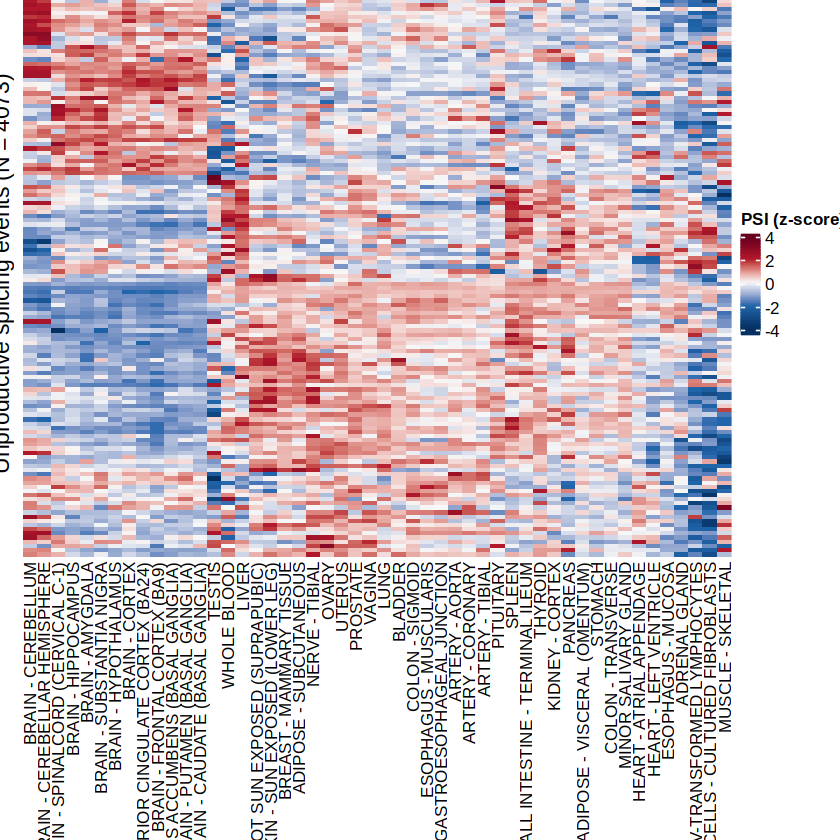

In [367]:
up_filtered_X <- up_X[intron_idx[intron_idx %in% top_psi[top_psi$cluster %in% top_pr$cluster,]$intron],cols_orders]
up_filtered_X %>% t()%>% scale() %>% t() %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


ht = draw(ht); column_order(ht); row_order(ht)


X_merge <- up_filtered_X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% as.data.frame()

X_merge['intron'] <- rownames(up_filtered_X)


up_psi_norm_filtered <- merge(up_psi[c('intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id')], 
      X_merge, by = c("intron"))


row_clusters <- row_order(ht)

# Convert list to a data frame for easy interpretation
cluster_df <- do.call(rbind, lapply(seq_along(row_clusters), function(i) {
  data.frame(intron = rownames(up_filtered_X)[row_clusters[[i]]], Cluster = i)
}))

colnames(cluster_df) <- c('intron', 'kcluster')
# View the first few rows
head(cluster_df)



up_psi_filter <- up_psi_norm_filtered %>% filter(intron %in% cluster_df$intron)
up_psi_filter <- merge(up_psi_filter, cluster_df, by = c("intron"))

In [337]:
# up_psi_filter

In [347]:
row_order <- row_order(ht)
col_order <- column_order(ht)
idx <- match(up_psi_filter[row_order['1'][[1]],]$GENE_ID, median_expression$GENE_ID)
out <- median_expression[idx[!is.na(idx)], ]

In [360]:
up_psi_filter$GENE_ID <- str_remove(up_psi_filter$gene_id, "\\..*$")
# median_expression$gene_id <- str_remove(median_expression$Name, "\\..*$")

In [362]:
cols_orders <- c(colnames(up_filtered_X)[col_order['3'][[1]]], colnames(up_filtered_X)[col_order['2'][[1]]], colnames(up_filtered_X)[col_order['1'][[1]]]) %>% toupper()

idx1 <- match(up_psi_filter[row_order['1'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx2 <- match(up_psi_filter[row_order['2'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx3 <- match(up_psi_filter[row_order['3'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx4 <- match(up_psi_filter[row_order['4'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx5 <- match(up_psi_filter[row_order['5'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx6 <- match(up_psi_filter[row_order['6'][[1]],]$GENE_ID, median_expression$GENE_ID)

rows_orders <- c(idx1, idx2, idx3, idx4, idx5, idx6)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



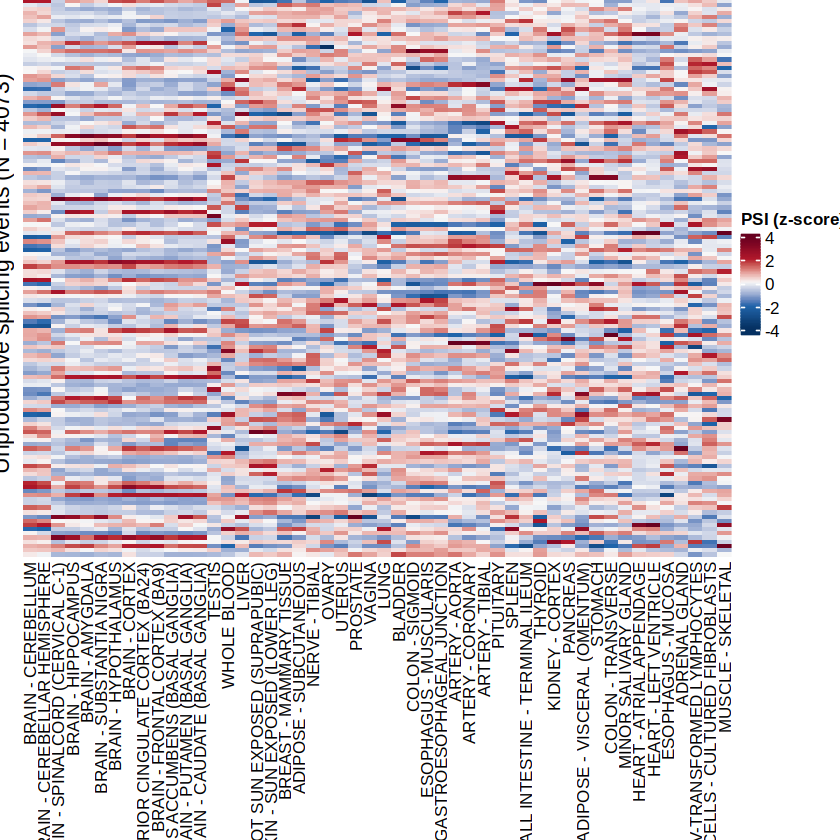

In [366]:
(median_expression[mexp_tissues][rows_orders, cols_orders] %>%log1p() %>% t() %>% scale() %>% t() %>% scale()) %>%
Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

In [354]:
up_psi_filter[row_order['1'][[1]],]

,intron,cluster,itype,ctype,gene_name,gene_id,TESTIS,WHOLE BLOOD,LIVER,SKIN - NOT SUN EXPOSED (SUPRAPUBIC),⋯,BRAIN - AMYGDALA,BRAIN - SUBSTANTIA NIGRA,BRAIN - HYPOTHALAMUS,BRAIN - CORTEX,BRAIN - ANTERIOR CINGULATE CORTEX (BA24),BRAIN - FRONTAL CORTEX (BA9),BRAIN - NUCLEUS ACCUMBENS (BASAL GANGLIA),BRAIN - PUTAMEN (BASAL GANGLIA),BRAIN - CAUDATE (BASAL GANGLIA),kcluster
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
45,chr18:47134704:47136301:clu_40557_-,chr18:clu_40557_-,UP,"PR,UP",HDHD2,ENSG00000167220.11,-0.30426616,-1.91668740,1.60088555,-0.67027759,⋯,1.38114717,1.2890141,1.11535228,0.5337104,0.69770837,0.28790010,0.96011628,0.9582616,0.9011036,3
46,chr18:9562075:9562921:clu_40378_-,chr18:clu_40378_-,UP,"PR,UP",PPP4R1,ENSG00000154845.15,0.21139378,0.08619306,-1.44749108,0.49022548,⋯,1.09239995,1.0338830,1.02443892,1.4505227,1.29785794,0.89858546,1.26773108,1.2430707,1.4818382,4
53,chr1:113700243:113700793:clu_3531_-,chr1:clu_3531_-,UP,"PR,UP",PHTF1,ENSG00000116793.15,-2.46945409,0.90329393,-0.19765212,0.85460303,⋯,-0.78476176,-1.1788262,-1.08159306,-1.7824251,-1.26861376,-1.82911331,-1.07750656,-1.0631620,-1.0609389,1
54,chr1:155611852:155611982:clu_1547_+,chr1:clu_1547_+,UP,"PR,UP",MSTO1,ENSG00000125459.14,-1.17901149,1.49416209,-1.64640594,0.25923148,⋯,-0.64584288,-0.7108805,-0.47700515,-0.7704186,0.01413171,-1.18862600,-0.54994241,-0.6695125,-1.0084688,2
55,chr1:155916709:155917498:clu_3886_-,chr1:clu_3886_-,UP,"PR,UP",KIAA0907,ENSG00000132680.10,-1.11297557,-1.12894185,0.20236057,0.89518922,⋯,-1.60789691,-1.3605715,-1.79903717,-1.0896992,-1.28922795,-1.38731662,-0.89853096,-0.7691080,-0.9976954,1
56,chr1:15874395:15876201:clu_272_+,chr1:clu_272_+,UP,"PR,UP",SPEN,ENSG00000065526.10,-1.10668733,-0.16410492,-0.24560066,1.02737982,⋯,1.63098284,1.8662798,0.61557004,-0.1593364,1.10224226,-0.03005241,0.43312044,1.4506974,0.8257735,6
57,chr1:161750145:161751654:clu_1691_+,chr1:clu_1691_+,UP,"PR,UP",DUSP12,ENSG00000081721.11,-1.31391182,-1.04871216,-0.39108544,-0.28507541,⋯,0.75838575,0.9957338,0.79389408,1.9491794,1.00451601,1.32577761,0.75722966,1.1870553,0.9141285,4
58,chr1:1703995:1704222:clu_2456_-,chr1:clu_2456_-,UP,"PR,UP",CDK11A,ENSG00000008128.22,-0.26971380,-0.66082667,-0.94899129,2.05829819,⋯,0.01641199,-0.2269163,-0.07397198,0.2964413,0.18361962,-0.45832051,-0.05319788,-0.1656267,-0.7576262,2
59,chr1:170536421:170539209:clu_1760_+,chr1:clu_1760_+,UP,"PR,UP",GORAB,ENSG00000120370.12,1.98070887,-0.08137260,0.40885684,1.76926157,⋯,-1.82248904,-1.0701544,-1.53169106,-0.6967880,-2.12095203,-1.41744697,-1.46197418,-1.5327353,-1.4732444,1


In [316]:
median_expression[median_expression$DESCRIPTION %in% top_psi$gene_name, 'BRAIN - CORTEX'] %>% median()

[1] 6.613085

In [317]:
colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )

In [318]:
legendBreaks <- seq(-4, 4, 2)
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")

colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )

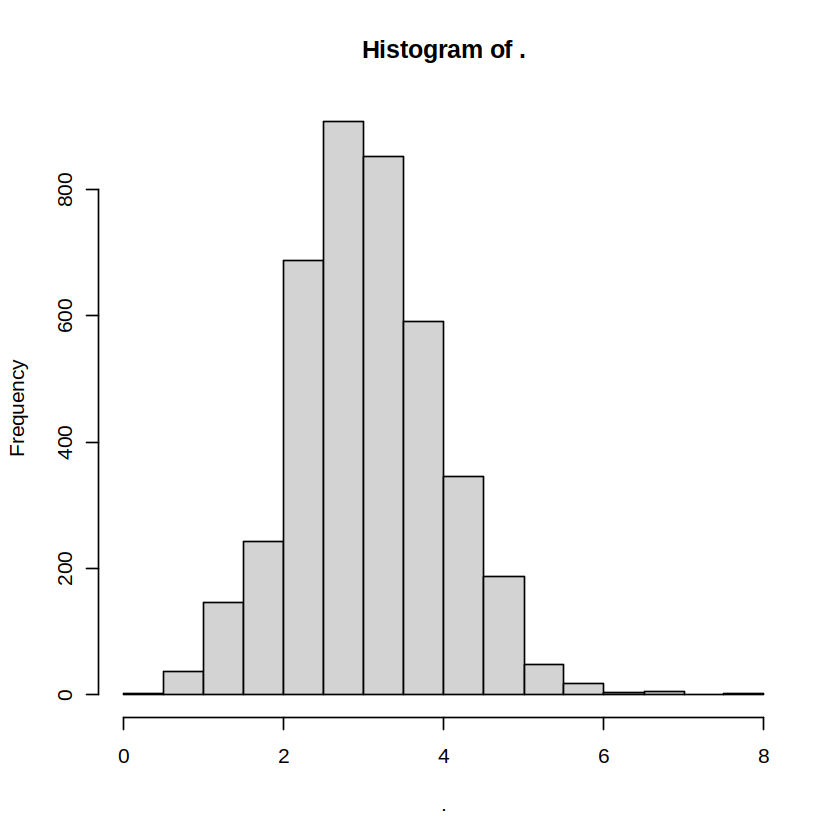

In [319]:
exp_X %>% pull(TESTIS) %>% log1p() %>% hist()

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



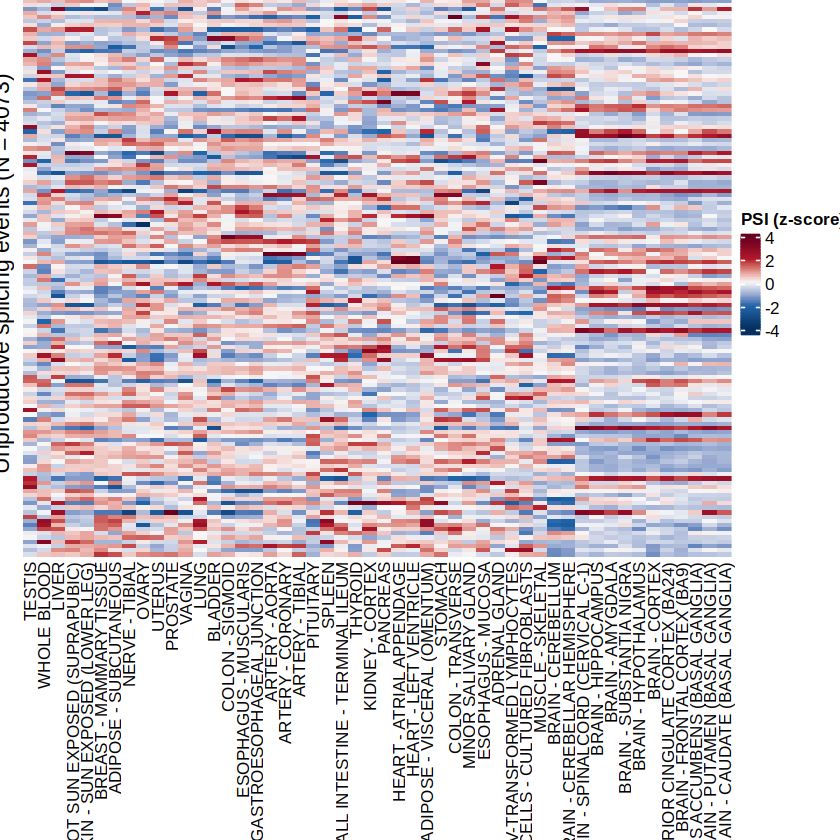

In [323]:
exp_X[rownames(exp_X)[intron_idx %in% top_psi[top_psi$cluster %in% top_pr$cluster,]$intron],] %>%
 log1p() %>% t() %>% scale() %>% t()%>% scale() %>% #t() %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

In [102]:
ht = draw(ht); column_order(ht); row_order(ht)


intron,cluster,gene_name,gene_id,mean_tissue
<chr>,<chr>,<chr>,<chr>,<dbl>
chr1:169869128:169870254:clu_4072_-,chr1:clu_4072_-,SCYL3,ENSG00000000457.13,0.2263280
chrX:65518465:65520701:clu_47524_-,chrX:clu_47524_-,LAS1L,ENSG00000001497.16,0.2604893
chr3:50100051:50103082:clu_8543_+,chr3:clu_8543_+,RBM5,ENSG00000003756.16,0.2927713
chr1:33024567:33031543:clu_2898_-,chr1:clu_2898_-,AK2,ENSG00000004455.16,0.1009647
chr19:35784317:35784494:clu_41528_+,chr19:clu_41528_+,ARHGAP33,ENSG00000004777.18,0.8185567
chr7:96169943:96170044:clu_18914_-,chr7:clu_18914_-,SLC25A13,ENSG00000004864.13,0.1687287
chr2:75690719:75694240:clu_7008_-,chr2:clu_7008_-,GCFC2,ENSG00000005436.13,0.1656465
chr7:87878133:87884978:clu_17632_+,chr7:clu_17632_+,DBF4,ENSG00000006634.7,0.1242192
chr5:134286559:134302589:clu_14607_-,chr5:clu_14607_-,CDKL3,ENSG00000006837.11,0.1643970


In [71]:
up_psi %>% filter(cluster %in% result$cluster)

intron,cluster,itype,ctype,gene_name,gene_id,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr10:100190968:100192458:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.083038952,0.240721568,0.1576749749,0.0875375386,⋯,0.128513713,0.0251768116,0.1197842448,0.063493705,0.030676155,0.209774067,0.208998645,0.158868440,0.1658607010,0.042327018
chr10:100190968:100193388:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.018799172,0.013974412,0.0105147510,0.0158132403,⋯,0.015678992,0.0107455347,0.0139786299,0.015714025,0.009786221,0.007654834,0.014776759,0.017518663,0.0105282523,0.019714040
chr10:100496431:100497666:clu_24486_-,chr10:clu_24486_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.072413095,0.033501595,0.0278579914,0.0282494295,⋯,0.046129174,0.0609825673,0.0277806331,0.035879371,0.047508131,0.099586731,0.061632157,0.060940716,0.0457710184,0.061426941
chr10:102727157:102727674:clu_23619_+,chr10:clu_23619_+,UP,"PR,UP",SFXN2,ENSG00000156398.12,0.070629567,0.062950734,0.0493375068,0.0556644231,⋯,0.063618766,0.0860148476,0.0756977765,0.059181904,0.060792731,0.081902598,0.079630486,0.095949676,0.0597884907,0.154672787
chr10:102727791:102728430:clu_23619_+,chr10:clu_23619_+,UP,"PR,UP",SFXN2,ENSG00000156398.12,0.098576630,0.120254378,0.0633413915,0.1017913539,⋯,0.093263528,0.1090432024,0.1264365352,0.115531984,0.082256101,0.168291997,0.089017101,0.119839570,0.0999974583,0.178756346
chr10:103398528:103399646:clu_23624_+,chr10:clu_23624_+,UP,"PR,UP",PDCD11,ENSG00000148843.13,0.032931871,0.043902412,0.0582868619,0.0451059620,⋯,0.040307572,0.0204800906,0.0499396346,0.048710242,0.057884507,0.017039959,0.024339171,0.022758558,0.0206837339,0.043190910
chr10:103399830:103400396:clu_23624_+,chr10:clu_23624_+,UP,"PR,UP",PDCD11,ENSG00000148843.13,0.161782087,0.199298934,0.1677076748,0.1914267567,⋯,0.194615011,0.0664317738,0.1753535156,0.177299011,0.195885982,0.114609837,0.183284969,0.203845531,0.1784521685,0.126725043
chr10:103897719:103898292:clu_24544_-,chr10:clu_24544_-,UP,"PR,UP",STN1,ENSG00000107960.10,0.037492406,0.037213480,0.0345100438,0.0410878272,⋯,0.049358155,0.0320495283,0.0530943570,0.055995802,0.059649497,0.018760497,0.059307953,0.045752006,0.0436780485,0.042549499
chr10:103898377:103898876:clu_24544_-,chr10:clu_24544_-,UP,"PR,UP",STN1,ENSG00000107960.10,0.041748491,0.043806749,0.0360830061,0.0512161693,⋯,0.062346750,0.0384380919,0.0542469053,0.061830990,0.045707938,0.016694422,0.070340943,0.044489903,0.0484928629,0.044699692


In [69]:
result# %>% dim()

cluster,gene_name,gene_id,median_tissue
<chr>,<chr>,<chr>,<dbl>
chr20:clu_44769_-,DPM1,ENSG00000000419.12,113.0
chr1:clu_4072_-,SCYL3,ENSG00000000457.13,19.0
chr6:clu_16914_-,FUCA2,ENSG00000001036.13,187.0
chr1:clu_2778_-,STPG1,ENSG00000001460.17,14.5
chrX:clu_47524_-,LAS1L,ENSG00000001497.16,94.0
chr7:clu_17676_+,ANKIB1,ENSG00000001629.9,43.0
chr7:clu_18875_-,KRIT1,ENSG00000001631.15,100.5
chr4:clu_11115_+,LAP3,ENSG00000002549.12,289.5
chrX:clu_46568_+,CD99,ENSG00000002586.18,1853.0


In [181]:
# counts
best_cluster_per_gene <- counts %>%
group_by(gene_id, cluster) %>%
  summarise(
    across(all_of(tissues), sum, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  # 2. Compute average across tissue columns
  rowwise() %>%
  mutate(mean_count = mean(c_across(all_of(tissues)), na.rm = TRUE)) %>%
  ungroup() %>%
  # 3. Pick the top cluster per gene
  group_by(genes) %>%
  slice_max(mean_count, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  select(gene_id, cluster, mean_count)


In [162]:
df_selected <- counts %>%
  # 1. count rows per gene × cluster
  count(gene_id, cluster, name = "n") %>%
  # 2. for each gene, keep the cluster with the largest count
  group_by(gene_id) %>%
  slice_max(n, n = 1, with_ties = FALSE) %>%
  # 3. join back to keep all original rows from that cluster
  select(-n) %>%
  inner_join(df, by = c("genes", "clusters"))

,Artery - Aorta,Brain - Cortex,Brain - Nucleus accumbens (basal ganglia),Esophagus - Muscularis,Adipose - Visceral (omentum),Adrenal gland,Artery - Coronary,Bladder,Brain - Amygdala,Brain - Anterior cingulate cortex (BA24),⋯,Breast - Mammary tissue,Cells - EBV-transformed lymphocytes,Colon - Sigmoid,Colon - Transverse,Liver,Muscle - Skeletal,Nerve - Tibial,Skin - Not sun exposed (suprapubic),Skin - Sun exposed (lower leg),Whole blood
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr10:100190968:100192458:clu_24474_-,0.0830389521,0.2407215680,0.1576749749,8.753754e-02,0.0817457972,0.0390286804,1.078209e-01,1.123610e-01,0.1533244101,0.1576481556,⋯,0.128513713,2.517681e-02,0.119784245,6.349370e-02,0.0306761548,0.209774067,0.2089986449,0.158868440,0.1658607010,0.042327018
chr10:100190968:100193388:clu_24474_-,0.0187991722,0.0139744120,0.0105147510,1.581324e-02,0.0131517192,0.0087858354,1.706494e-02,1.487181e-02,0.0070337334,0.0149683292,⋯,0.015678992,1.074553e-02,0.013978630,1.571402e-02,0.0097862207,0.007654834,0.0147767594,0.017518663,0.0105282523,0.019714040
chr10:100496431:100497666:clu_24486_-,0.0724130949,0.0335015945,0.0278579914,2.824943e-02,0.0487843244,0.0411267387,6.682671e-02,3.349274e-02,0.0453758271,0.0355063797,⋯,0.046129174,6.098257e-02,0.027780633,3.587937e-02,0.0475081311,0.099586731,0.0616321571,0.060940716,0.0457710184,0.061426941
chr10:100498207:100499159:clu_24487_-,0.2903566590,0.2475714295,0.2408751219,2.417582e-01,0.2519950591,0.2250830481,2.518879e-01,2.057754e-01,0.2336802285,0.2070391569,⋯,0.274270738,1.805201e-01,0.211172139,1.859468e-01,0.2087604874,0.112935032,0.3015598773,0.245051415,0.2907946237,0.174686816
chr10:100499598:100500109:clu_24489_-,0.2925359714,0.1932268198,0.2161216724,3.333732e-01,0.3109713445,0.2645810989,3.212605e-01,3.330570e-01,0.2203847746,0.1855458576,⋯,0.298539935,2.496546e-01,0.340211933,3.210916e-01,0.3289088184,0.235171554,0.3016240295,0.277442169,0.2732430602,0.308342210
chr10:100500159:100501653:clu_24489_-,0.0198316885,0.0121058777,0.0114142768,2.377158e-02,0.0289272968,0.0166842274,2.344295e-02,1.898552e-02,0.0093393837,0.0030634849,⋯,0.025705299,2.256364e-02,0.025307736,2.808938e-02,0.0266000721,0.011182153,0.0200733426,0.025766692,0.0226865145,0.051886185
chr10:100500159:100502253:clu_24489_-,0.3497426399,0.2080576272,0.2367899689,3.657433e-01,0.3130473393,0.2760698203,3.460934e-01,3.842562e-01,0.2466977384,0.2128421836,⋯,0.310000473,2.806946e-01,0.366285839,3.487636e-01,0.3487910640,0.263440839,0.3216138856,0.294298794,0.2883121341,0.306227447
chr10:100501710:100502253:clu_24489_-,0.0209077756,0.0109099374,0.0097369867,2.159134e-02,0.0244459336,0.0159135194,2.135289e-02,1.592270e-02,0.0154190154,0.0033987323,⋯,0.028247605,2.172668e-02,0.021838522,2.633038e-02,0.0239713447,0.008932081,0.0194965340,0.019885354,0.0267613337,0.048971140
chr10:100508048:100508460:clu_24491_-,0.0009771331,0.1206386417,0.0488193401,3.295422e-04,0.0010148969,0.0060018594,9.180308e-04,1.528974e-03,0.0208581362,0.0715637230,⋯,0.001027095,2.806301e-06,0.001713852,1.777032e-03,0.0029534724,0.002395735,0.0023793146,0.002206053,0.0011308290,0.002844602


In [157]:
column_ha

A HeatmapAnnotation object with 1 annotation
  name: heatmap_annotation_0 
  position: column 
  items: 50 
  width: 1npc 
  height: 5mm 
  this object is subsetable
  13.4671666666667mm extension on the right 

   name annotation_type color_mapping height
 Tissue discrete vector  user-defined    5mm

In [155]:
colfunc('Testis')

[1] "#67001FFF"

In [142]:
cols_orders[!(cols_orders %in% colnames(median_expression))]

[1] "BRAIN - SPINALCORD (CERVICAL C-1)"

In [137]:
cols_orders[4]

[1] "SKIN - NOT SUN EXPOSED (SUPRAPUBIC)"

In [144]:
colnames(median_expression)[21]

[1] "BRAIN - SPINAL CORD (CERVICAL C-1)"

In [145]:
colnames(median_expression)[21] == 'BRAIN - SPINALCORD (CERVICAL C-1)'


[1] FALSE